# Building Electricity Consumption Prediction
## A Comparative Study of Linear Regression and Support Vector Regression with Lag-Based Feature Engineering

---

**Course**: Deep Learning for Electrical Engineering (ABK6BAB3)
**Program**: Magister Teknik Elektro, Telkom University
**Project Type**: Mini Project, Mid-Term Examination

---

### Case Study

PT. Cahaya Nusantara Energy operates office buildings and shopping centers
across multiple metropolitan areas in Indonesia. The company seeks to deploy
a data-driven model to forecast appliance-level energy consumption (in Wh)
at 10-minute intervals, enabling demand-response programs, peak-load shaving,
and anomaly detection within their building management systems.

### Dataset

This study uses the **Appliances Energy Prediction** dataset from the UCI
Machine Learning Repository (Candanedo et al., 2017), comprising 19,735
sensor records collected at 10-minute intervals over 4.5 months from a
low-energy residential building. Each record includes 28 features describing
indoor and outdoor environmental conditions, plus the target variable
(appliance energy consumption in Wh).

### Project Specification and Compliance

The pipeline implemented in this notebook fulfills four mandatory stages
defined by the project specification:

| Stage | Description |
|:-:|---|
| **1** | **Feature Engineering**, exploratory data analysis (distribution, missing values, outliers), correlation heatmap, normalization/standardization, feature selection (removal of redundant features), and quantitative comparison of model performance before vs. after feature engineering. |
| **2** | **Baseline Modeling**, Linear Regression and Support Vector Regression evaluated on **80:20** and **70:30** train-test splits, with **5-fold cross-validation** and full evaluation metrics (R-squared, MAE, RMSE, MAPE). |
| **3** | **Hyperparameter Tuning**, Grid Search and Randomized Search Cross-Validation with relevant parameter grids; before-vs-after comparison; recording of best parameters and best scores. |
| **4** | **Analytical Report**, justification of model selection, interpretation of evaluation metrics, error/diagnostic plot visualizations, and recommendations for real-world deployment. |

### Methodological Note on Computational Constraints

Support Vector Regression has a training cost between O(n^2) and O(n^3) in
the number of training observations. Full SVR training on the 15,672 samples
of the 80:20 training set is intractable on standard hardware. As a
methodological compromise, the SVR model is trained on a random subsample
of 5,000 training observations during baseline evaluation, baseline
cross-validation, and final inference, and on a smaller subsample of 3,500
observations during the randomized hyperparameter search. This approach is
standard practice in the literature for kernel-SVR on datasets exceeding
10,000 samples. The use of subsampling is acknowledged here as an explicit
limitation of the present study; this limitation will be revisited in the
discussion section.

### Document Structure

This notebook is organized into eleven sections, each implementing one
component of the pipeline:

- **Section 0**: Environment setup and library imports
- **Section 1**: Dataset loading and feature description
- **Section 2**: Exploratory data analysis (Stage 1)
- **Section 3**: Feature engineering and feature selection (Stage 1)
- **Section 4**: Data preparation, train-test splits and standardization
- **Section 5**: Baseline modeling, Linear Regression and SVR (Stage 2)
- **Section 6**: Hyperparameter tuning (Stage 3)
- **Section 7**: Final model selection and justification
- **Section 8**: Diagnostic analysis and visualization (Stage 4)
- **Section 9**: Metric interpretation and deployment recommendations (Stage 4)
- **Section 10**: Inference experiment on unseen test samples
- **Section 11**: Executive summary and limitations

---

## Section 0. Environment Setup and Library Imports

This section imports the libraries required for the end-to-end pipeline. A
fixed random seed (`RANDOM_STATE = 42`) is established to ensure
reproducibility of results across all stochastic operations (data splits,
cross-validation folds, randomized hyperparameter search, and SVR
sub-sampling).

In [1]:
# Core scientific computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# Statistical analysis
from scipy import stats

# Machine learning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

# Utilities
import warnings
import time
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Visualization defaults
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'semibold'

# Color palette adopted throughout the notebook
PALETTE = {
    'primary':   '#2E4057',  # deep navy   - primary plot color
    'secondary': '#DA7422',  # amber       - secondary / contrast
    'accent':    '#048A81',  # teal        - positive emphasis
    'success':   '#54C6BB',  # mint        - low-magnitude values
    'warning':   '#F4A261',  # light amber - warning
    'danger':    '#E63946',  # red         - error / negative
    'muted':     '#8D99AE',  # slate       - background / neutral
}
sns.set_palette([
    PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'],
    PALETTE['warning'], PALETTE['danger']
])

# Environment summary
import sklearn
print('=' * 65)
print(' ENVIRONMENT INITIALIZATION')
print('=' * 65)
print(f'  NumPy        : {np.__version__}')
print(f'  Pandas       : {pd.__version__}')
print(f'  Scikit-learn : {sklearn.__version__}')
print(f'  Random seed  : {RANDOM_STATE}')
print('=' * 65)

 ENVIRONMENT INITIALIZATION
  NumPy        : 2.0.2
  Pandas       : 2.2.2
  Scikit-learn : 1.6.1
  Random seed  : 42


## Section 1. Dataset Loading and Feature Description

The dataset is loaded from a local CSV file. The `date` column is parsed
into a `datetime64` object to enable extraction of temporal features
(hour, day of week, month). Records are sorted chronologically to preserve
the temporal ordering required for lag-feature construction.

In [2]:
DATA_PATH = 'KAG_energydata_complete.csv'

df_raw = pd.read_csv(DATA_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f'Number of records  : {df_raw.shape[0]:,}')
print(f'Number of columns  : {df_raw.shape[1]}')
print(f'Time range         : {df_raw["date"].min()}  to  {df_raw["date"].max()}')
print(f'Total duration     : {(df_raw["date"].max() - df_raw["date"].min()).days} days')
print(f'Sampling interval  : 10 minutes')
df_raw.head(3)

Number of records  : 19,735
Number of columns  : 29
Time range         : 2016-01-11 17:00:00  to  2016-05-27 18:00:00
Total duration     : 137 days
Sampling interval  : 10 minutes


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668


In [3]:
feature_catalog = pd.DataFrame([
    ('date',        'Timestamp of observation (10-minute interval)',     'Temporal'),
    ('Appliances',  'Energy consumption of household appliances (Wh)',   'Target'),
    ('lights',      'Energy consumption of light fixtures (Wh)',         'Internal'),
    ('T1 to T9',    'Indoor temperature in nine zones (degree Celsius)', 'Internal'),
    ('RH_1 to RH_9','Indoor relative humidity in nine zones (percent)',  'Internal'),
    ('T_out',       'Outdoor temperature (degree Celsius)',              'External'),
    ('RH_out',      'Outdoor relative humidity (percent)',               'External'),
    ('Press_mm_hg', 'Atmospheric pressure (mm Hg)',                      'External'),
    ('Windspeed',   'Wind speed (m/s)',                                  'External'),
    ('Visibility',  'Visibility distance (km)',                          'External'),
    ('Tdewpoint',   'Dew-point temperature (degree Celsius)',            'External'),
    ('rv1, rv2',    'Random noise variables (will be dropped)',          'Noise'),
], columns=['Variable', 'Description', 'Category'])

print('FEATURE CATALOG')
print('=' * 90)
feature_catalog

FEATURE CATALOG


,Variable,Description,Category
0,date,Timestamp of observation (10-minute interval),Temporal
1,Appliances,Energy consumption of household appliances (Wh),Target
2,lights,Energy consumption of light fixtures (Wh),Internal
3,T1 to T9,Indoor temperature in nine zones (degree Celsius),Internal
4,RH_1 to RH_9,Indoor relative humidity in nine zones (percent),Internal
5,T_out,Outdoor temperature (degree Celsius),External
6,RH_out,Outdoor relative humidity (percent),External
7,Press_mm_hg,Atmospheric pressure (mm Hg),External
8,Windspeed,Wind speed (m/s),External
9,Visibility,Visibility distance (km),External


---
## Section 2. Stage 1: Exploratory Data Analysis

Exploratory data analysis is conducted to characterize the dataset, identify
quality issues (missing values, duplicates), examine the statistical
distribution of the target variable, detect outliers, and discover temporal
patterns. The findings of this section directly motivate the feature
engineering choices made in Section 3.

### 2.1. Data Quality Assessment

In [4]:
print('DATA TYPES')
print('=' * 60)
print(df_raw.dtypes.value_counts().to_string())
print()

print('MISSING VALUES')
print('=' * 60)
n_missing = df_raw.isnull().sum().sum()
if n_missing == 0:
    print('  No missing values detected across all columns.')
else:
    print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print()

print('TIMESTAMP DUPLICATES')
print('=' * 60)
n_dup = df_raw['date'].duplicated().sum()
print(f'  Number of duplicate timestamps: {n_dup}')

DATA TYPES
float64           26
int64              2
datetime64[ns]     1

MISSING VALUES
  No missing values detected across all columns.

TIMESTAMP DUPLICATES
  Number of duplicate timestamps: 0


In [5]:
print('DESCRIPTIVE STATISTICS')
print('=' * 90)
df_raw.drop(columns=['date']).describe().T.round(2)

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.69,102.52,10.00,50.00,60.00,100.00,1080.00
lights,19735.0,3.80,7.94,0.00,0.00,0.00,0.00,70.00
T1,19735.0,21.69,1.61,16.79,20.76,21.60,22.60,26.26
RH_1,19735.0,40.26,3.98,27.02,37.33,39.66,43.07,63.36
T2,19735.0,20.34,2.19,16.10,18.79,20.00,21.50,29.86
RH_2,19735.0,40.42,4.07,20.46,37.90,40.50,43.26,56.03
T3,19735.0,22.27,2.01,17.20,20.79,22.10,23.29,29.24
RH_3,19735.0,39.24,3.25,28.77,36.90,38.53,41.76,50.16
T4,19735.0,20.86,2.04,15.10,19.53,20.67,22.10,26.20
RH_4,19735.0,39.03,4.34,27.66,35.53,38.40,42.16,51.09


### 2.2. Distribution of the Target Variable

The target variable `Appliances` (energy consumption in Wh) exhibits strong
positive skew: the majority of observations fall in the 50 to 100 Wh range
(representing idle and low-usage states), while a long upper tail captures
peak-demand events. This characteristic motivates the use of a logarithmic
transformation $y' = \log(1+y)$ in subsequent modeling, which both reduces
skewness and improves residual homoscedasticity for least-squares
estimation.

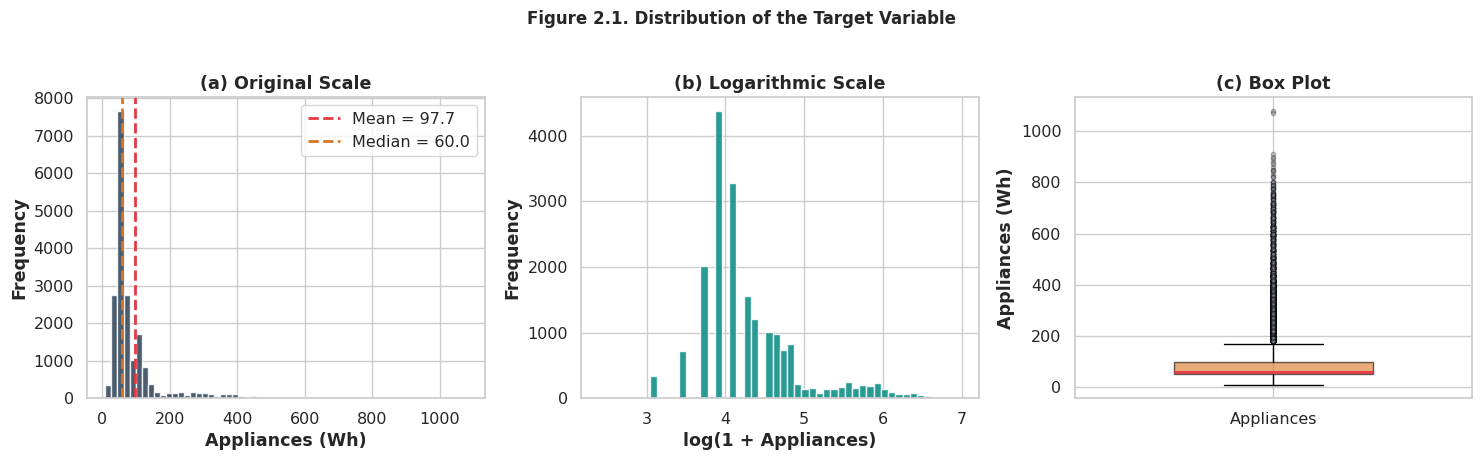

Skewness (original scale)  : 3.386 (strongly right-skewed)
Skewness (log scale)       : 1.190 (approximately symmetric)
Kurtosis (original scale)  : 13.668

Implication: the log(1+y) transformation will be applied to the target
prior to fitting linear and kernel models in order to stabilize
variance and bring the residual distribution closer to normality.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(df_raw['Appliances'], bins=60, color=PALETTE['primary'],
             alpha=0.85, edgecolor='white')
axes[0].axvline(df_raw['Appliances'].mean(), color=PALETTE['danger'],
                linestyle='--', lw=2,
                label=f'Mean = {df_raw["Appliances"].mean():.1f}')
axes[0].axvline(df_raw['Appliances'].median(), color=PALETTE['secondary'],
                linestyle='--', lw=2,
                label=f'Median = {df_raw["Appliances"].median():.1f}')
axes[0].set_xlabel('Appliances (Wh)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('(a) Original Scale')
axes[0].legend()

log_target = np.log1p(df_raw['Appliances'])
axes[1].hist(log_target, bins=50, color=PALETTE['accent'],
             alpha=0.85, edgecolor='white')
axes[1].set_xlabel('log(1 + Appliances)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('(b) Logarithmic Scale')

axes[2].boxplot(df_raw['Appliances'], vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=PALETTE['secondary'], alpha=0.6),
                medianprops=dict(color=PALETTE['danger'], lw=2),
                flierprops=dict(marker='o',
                                markerfacecolor=PALETTE['muted'],
                                markersize=3, alpha=0.3))
axes[2].set_ylabel('Appliances (Wh)')
axes[2].set_title('(c) Box Plot')
axes[2].set_xticklabels(['Appliances'])

plt.suptitle('Figure 2.1. Distribution of the Target Variable',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Skewness (original scale)  : {df_raw["Appliances"].skew():.3f}'
      ' (strongly right-skewed)')
print(f'Skewness (log scale)       : {log_target.skew():.3f}'
      ' (approximately symmetric)')
print(f'Kurtosis (original scale)  : {df_raw["Appliances"].kurtosis():.3f}')
print()
print('Implication: the log(1+y) transformation will be applied to the target')
print('prior to fitting linear and kernel models in order to stabilize')
print('variance and bring the residual distribution closer to normality.')

### 2.3. Outlier Analysis (Interquartile Range Method)

Outliers are detected using the standard 1.5 IQR rule: an observation is
flagged as an outlier if it falls below $Q_1 - 1.5 \cdot \mathrm{IQR}$ or
above $Q_3 + 1.5 \cdot \mathrm{IQR}$, where $\mathrm{IQR} = Q_3 - Q_1$.

In this domain, however, target outliers are not measurement errors: they
correspond to genuine peak-demand events that are operationally important
to forecast. The chosen mitigation strategy is therefore to retain all
outlier observations in the dataset and rely on the log-transform to
dampen their influence on the loss function.

In [7]:
def iqr_outliers(series, k=1.5):
    """Flag outliers using the Tukey IQR rule."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper


numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

outlier_records = []
for col in numeric_cols:
    mask, lower, upper = iqr_outliers(df_raw[col])
    outlier_records.append({
        'Feature':      col,
        'n_outliers':   mask.sum(),
        'pct_outliers': 100 * mask.sum() / len(df_raw),
        'Lower bound':  lower,
        'Upper bound':  upper,
    })
outlier_df = (pd.DataFrame(outlier_records)
              .sort_values('pct_outliers', ascending=False))

print('TOP 10 FEATURES BY OUTLIER COUNT')
print('=' * 75)
outlier_df.head(10).round(2)

TOP 10 FEATURES BY OUTLIER COUNT


,Feature,n_outliers,pct_outliers,Lower bound,Upper bound
1,lights,4483,22.72,0.00,0.00
24,Visibility,2522,12.78,12.50,56.50
0,Appliances,2138,10.83,-25.00,175.00
11,RH_5,1330,6.74,33.01,66.06
4,T2,546,2.77,14.72,25.56
2,T1,515,2.61,18.00,25.36
12,T6,515,2.61,-7.82,22.70
20,T_out,436,2.21,-6.45,20.52
22,RH_out,239,1.21,38.33,123.67
5,RH_2,235,1.19,29.86,51.30


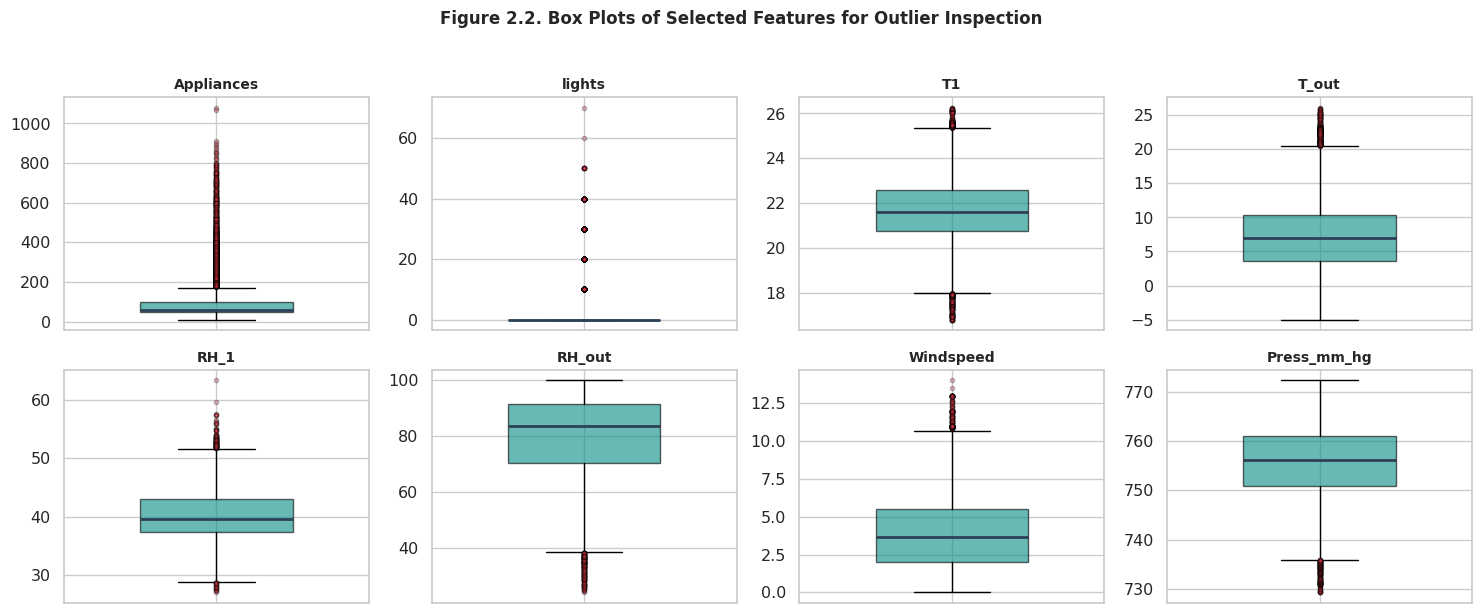

Number of outliers in target: 2138 (10.8 percent)

Treatment policy: target outliers are retained because they correspond
to peak-demand events that are operationally important to forecast.
The log-transform applied later will dampen their influence on the loss.


In [8]:
key_cols = ['Appliances', 'lights', 'T1', 'T_out',
            'RH_1', 'RH_out', 'Windspeed', 'Press_mm_hg']

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.flat, key_cols):
    ax.boxplot(df_raw[col], vert=True, patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=PALETTE['accent'], alpha=0.6),
               medianprops=dict(color=PALETTE['primary'], lw=2),
               flierprops=dict(marker='o',
                               markerfacecolor=PALETTE['danger'],
                               markersize=3, alpha=0.3))
    ax.set_title(col, fontsize=10)
    ax.set_xticklabels([])

plt.suptitle('Figure 2.2. Box Plots of Selected Features for Outlier Inspection',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_target_out = iqr_outliers(df_raw['Appliances'])[0].sum()
print(f'Number of outliers in target: {n_target_out} '
      f'({100 * n_target_out / len(df_raw):.1f} percent)')
print()
print('Treatment policy: target outliers are retained because they correspond')
print('to peak-demand events that are operationally important to forecast.')
print('The log-transform applied later will dampen their influence on the loss.')

### 2.4. Temporal Pattern Analysis

Energy consumption in buildings is driven by occupant behavior, which
exhibits strong daily and weekly periodicity. This subsection visualizes
those patterns to motivate the temporal feature engineering performed in
Section 3.

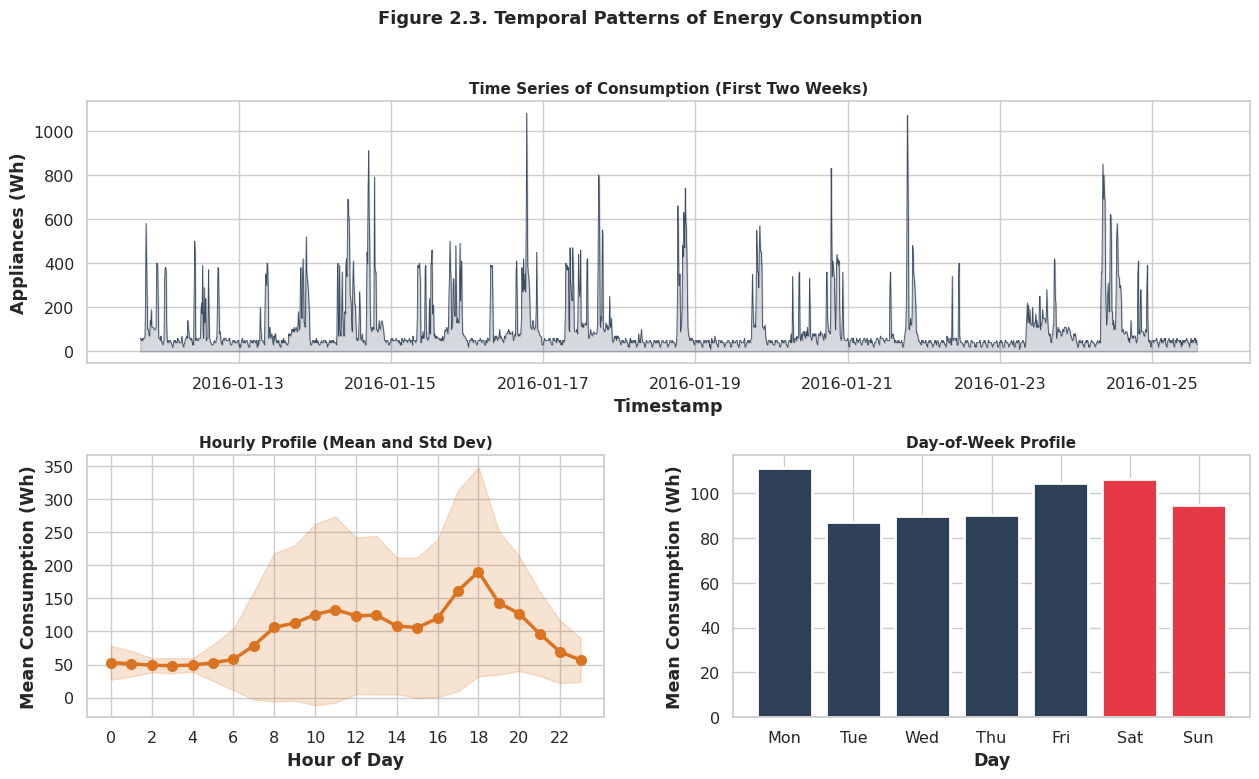

Observed temporal patterns:
  Daily peak hour          : 18:00
  Daily minimum hour       : 03:00
  Weekly highest day       : Monday
  Weekly lowest day        : Tuesday

Implication: hour, day-of-week, and is_weekend will be added as
features. Cyclical sin/cos encoding will be used to preserve the
natural periodicity (e.g., to ensure hour 23 and hour 0 are encoded
as adjacent values).


In [9]:
df_temporal = df_raw.copy()
df_temporal['hour']      = df_temporal['date'].dt.hour
df_temporal['dayofweek'] = df_temporal['date'].dt.dayofweek
df_temporal['day_name']  = df_temporal['date'].dt.day_name()
df_temporal['month']     = df_temporal['date'].dt.month

fig = plt.figure(figsize=(15, 8))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

ax1 = fig.add_subplot(gs[0, :])
sample = df_raw.iloc[:2000]
ax1.plot(sample['date'], sample['Appliances'],
         color=PALETTE['primary'], lw=0.6, alpha=0.9)
ax1.fill_between(sample['date'], sample['Appliances'],
                 color=PALETTE['primary'], alpha=0.2)
ax1.set_title('Time Series of Consumption (First Two Weeks)', fontsize=11)
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Appliances (Wh)')

ax2 = fig.add_subplot(gs[1, 0])
hour_stats = (df_temporal.groupby('hour')['Appliances']
              .agg(['mean', 'std']).reset_index())
ax2.plot(hour_stats['hour'], hour_stats['mean'], marker='o',
         color=PALETTE['secondary'], lw=2.5, markersize=7)
ax2.fill_between(hour_stats['hour'],
                 hour_stats['mean'] - hour_stats['std'],
                 hour_stats['mean'] + hour_stats['std'],
                 color=PALETTE['secondary'], alpha=0.2)
ax2.set_title('Hourly Profile (Mean and Std Dev)', fontsize=11)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Mean Consumption (Wh)')
ax2.set_xticks(range(0, 24, 2))

ax3 = fig.add_subplot(gs[1, 1])
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']
day_mean = (df_temporal.groupby('day_name')['Appliances']
            .mean().reindex(day_order))
bar_colors = [PALETTE['primary'] if d not in ['Saturday', 'Sunday']
              else PALETTE['danger'] for d in day_order]
ax3.bar(range(7), day_mean.values, color=bar_colors,
        edgecolor='white', lw=2)
ax3.set_title('Day-of-Week Profile', fontsize=11)
ax3.set_xlabel('Day')
ax3.set_ylabel('Mean Consumption (Wh)')
ax3.set_xticks(range(7))
ax3.set_xticklabels([d[:3] for d in day_order])

plt.suptitle('Figure 2.3. Temporal Patterns of Energy Consumption',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print('Observed temporal patterns:')
print(f'  Daily peak hour          : '
      f'{int(hour_stats.loc[hour_stats["mean"].idxmax(), "hour"]):02d}:00')
print(f'  Daily minimum hour       : '
      f'{int(hour_stats.loc[hour_stats["mean"].idxmin(), "hour"]):02d}:00')
print(f'  Weekly highest day       : {day_mean.idxmax()}')
print(f'  Weekly lowest day        : {day_mean.idxmin()}')
print()
print('Implication: hour, day-of-week, and is_weekend will be added as')
print('features. Cyclical sin/cos encoding will be used to preserve the')
print('natural periodicity (e.g., to ensure hour 23 and hour 0 are encoded')
print('as adjacent values).')

### 2.5. Pearson Correlation Heatmap

The Pearson linear correlation coefficient is computed pair-wise across all
numeric features. The heatmap reveals two important patterns:

1. **Strong intra-zone temperature correlations**, temperatures across the
   nine indoor zones are mutually correlated above 0.85, suggesting
   redundancy.
2. **Near-perfect correlation between $T_6$ (kitchen, exterior wall) and
   $T_{\mathrm{out}}$ (outdoor)**, $|r| > 0.95$, again indicating redundancy.

These observations directly motivate the feature selection step in
Section 3.1, in which one feature from each redundant pair is removed.

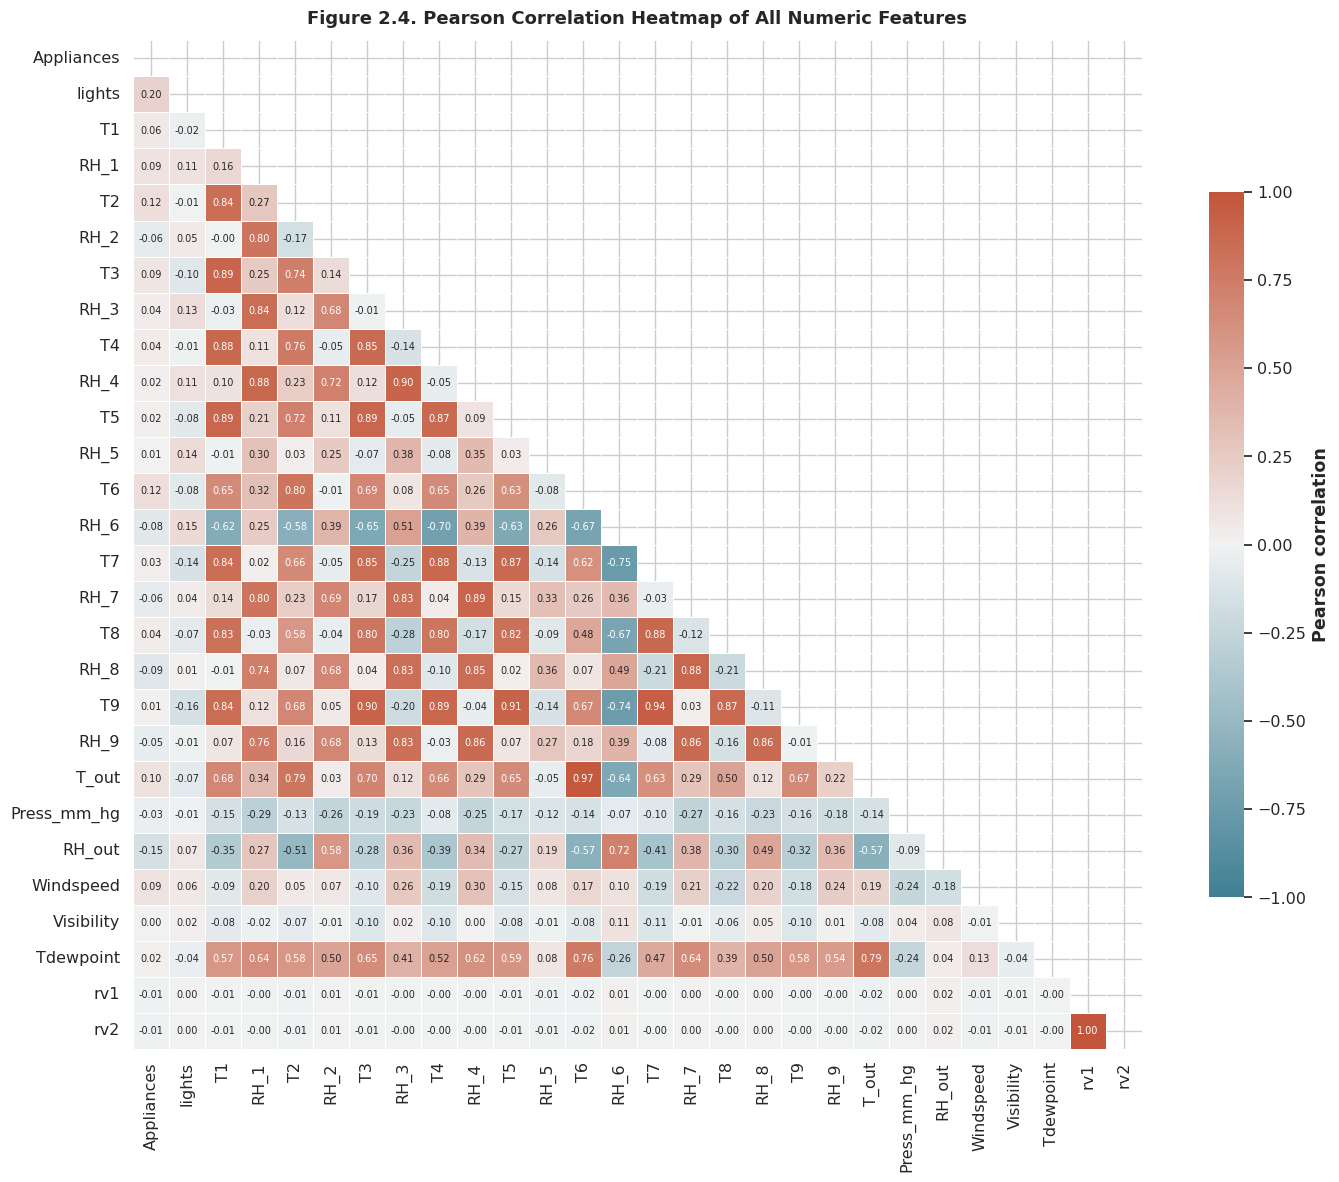

In [10]:
corr_matrix = df_raw.drop(columns=['date']).corr()

fig, ax = plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson correlation'},
    annot=True, fmt='.2f', annot_kws={'size': 7},
    ax=ax,
)
ax.set_title('Figure 2.4. Pearson Correlation Heatmap of All Numeric Features',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

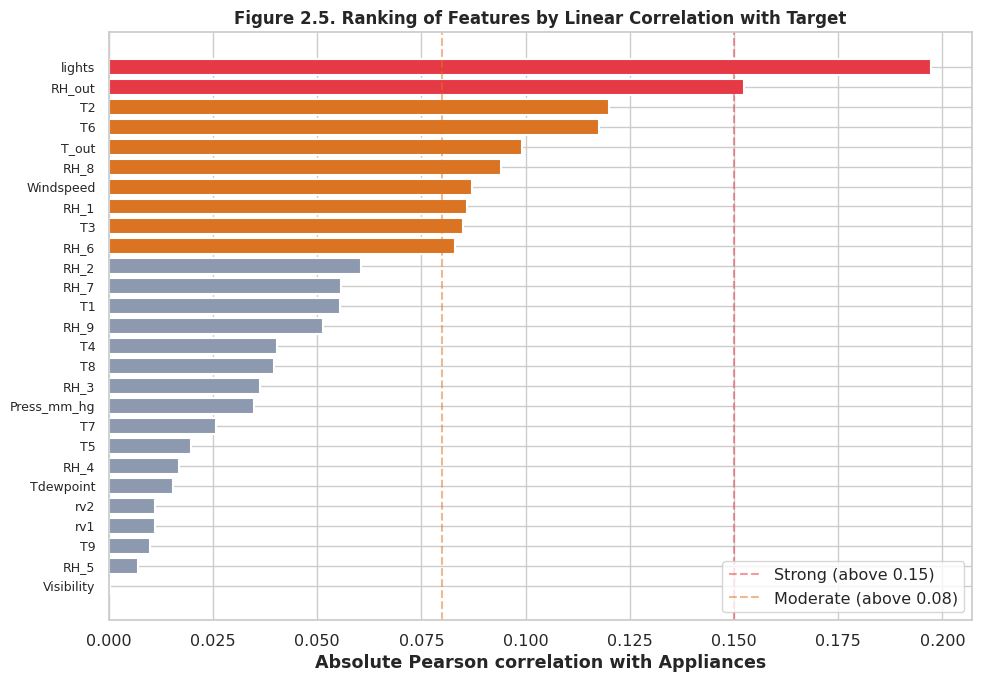

Top 5 features by linear correlation with the target:
  1. lights          -> 0.197
  2. RH_out          -> 0.152
  3. T2              -> 0.120
  4. T6              -> 0.118
  5. T_out           -> 0.099

Observation: all individual features exhibit relatively weak linear
correlation with the target (highest absolute value below 0.25). This
confirms that nonlinear modeling and engineered lag features will be
necessary to obtain useful predictive performance.


In [11]:
target_corr = (corr_matrix['Appliances']
               .drop('Appliances')
               .abs()
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [PALETTE['danger']  if v > 0.15 else
              PALETTE['secondary'] if v > 0.08 else
              PALETTE['muted']
              for v in target_corr.values]
ax.barh(range(len(target_corr)), target_corr.values, color=bar_colors,
        edgecolor='white', lw=1.5)
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Absolute Pearson correlation with Appliances')
ax.set_title('Figure 2.5. Ranking of Features by Linear Correlation with Target',
             fontsize=12, fontweight='bold')
ax.axvline(0.15, color=PALETTE['danger'], linestyle='--', alpha=0.5,
           label='Strong (above 0.15)')
ax.axvline(0.08, color=PALETTE['secondary'], linestyle='--', alpha=0.5,
           label='Moderate (above 0.08)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('Top 5 features by linear correlation with the target:')
for rank, (feat, val) in enumerate(target_corr.head(5).items(), 1):
    print(f'  {rank}. {feat:15s} -> {val:.3f}')

print()
print('Observation: all individual features exhibit relatively weak linear')
print('correlation with the target (highest absolute value below 0.25). This')
print('confirms that nonlinear modeling and engineered lag features will be')
print('necessary to obtain useful predictive performance.')

---
## Section 3. Stage 1 (continued): Feature Engineering

Based on the EDA findings, a structured feature engineering pipeline is
applied. The new features fall into six categories:

| Category | Features | Rationale |
|---|---|---|
| Calendar | `hour`, `dayofweek`, `month`, `is_weekend` | Capture daily and weekly periodicity revealed in Section 2.4. |
| Cyclical encoding | `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos` | Preserve cyclic continuity (hour 23 and hour 0 should be adjacent). |
| Lag features | $\log y_{t-k}$ for $k \in \{1, 2, 3, 6, 12, 24, 144\}$ | Exploit strong temporal autocorrelation. The lag of 144 corresponds to one full day. |
| Rolling statistics | mean and standard deviation of $\log y$ over windows $\{3, 6, 12, 24\}$ | Capture short-term trend and volatility. The series is shifted by one before rolling to prevent target leakage. |
| First differences | $\log y_{t-1} - \log y_{t-2}$ and $\log y_{t-2} - \log y_{t-3}$ | Capture the local rate of change. |
| Interactions | $T_{\mathrm{out}} \cdot \sin(\mathrm{hour})$ and $T_{\mathrm{out}} \cdot \cos(\mathrm{hour})$ | Represent the joint effect of outdoor temperature and time of day. |

In [12]:
def engineer_features(df_input):
    """Apply the complete feature engineering pipeline.

    Parameters
    ----------
    df_input : pandas.DataFrame
        Raw dataframe with at minimum a 'date' column and an 'Appliances'
        column. Must contain a 'T_out' column for the interaction features.

    Returns
    -------
    pandas.DataFrame
        Augmented dataframe. Rows containing NaN values produced by the lag
        and rolling operations are dropped.
    """
    df = df_input.copy().sort_values('date').reset_index(drop=True)

    # 1. Calendar features
    df['hour']       = df['date'].dt.hour
    df['dayofweek']  = df['date'].dt.dayofweek
    df['month']      = df['date'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # 2. Cyclical encoding
    df['hour_sin']  = np.sin(2 * np.pi * df['hour']      / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour']      / 24)
    df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)

    # 3. Lag features on the log target
    y_log = np.log1p(df['Appliances'])
    for lag in [1, 2, 3, 6, 12, 24, 144]:
        df[f'ylog_lag_{lag}'] = y_log.shift(lag)

    # 4. Rolling statistics on the log target.
    #    Shift by 1 ensures that the window only uses past observations.
    for window in [3, 6, 12, 24]:
        df[f'ylog_rm_{window}'] = y_log.shift(1).rolling(window).mean()
        df[f'ylog_rs_{window}'] = y_log.shift(1).rolling(window).std()

    # 5. First-difference features
    df['ylog_d1'] = y_log.shift(1) - y_log.shift(2)
    df['ylog_d2'] = y_log.shift(2) - y_log.shift(3)

    # 6. Outdoor-temperature interaction terms
    df['Tout_hsin'] = df['T_out'] * df['hour_sin']
    df['Tout_hcos'] = df['T_out'] * df['hour_cos']

    # Drop rows with NaN produced by lag and rolling operations
    return df.dropna().reset_index(drop=True)


# Apply the pipeline and discard the noise variables rv1 and rv2
df_feat = engineer_features(df_raw).drop(columns=['rv1', 'rv2'])

print('FEATURE ENGINEERING SUMMARY')
print('=' * 65)
print(f'  Before  : {df_raw.shape[1]:>3d} columns x {df_raw.shape[0]:>6,} rows')
print(f'  After   : {df_feat.shape[1]:>3d} columns x {df_feat.shape[0]:>6,} rows')
print(f'  Dropped : {df_raw.shape[0] - df_feat.shape[0]:>3d} rows '
      '(NaN from lag/rolling operations)')

new_features = [c for c in df_feat.columns if c not in df_raw.columns]
print(f'\nNew features added ({len(new_features)}):')
for i in range(0, len(new_features), 4):
    print('  ' + '  |  '.join(f'{f:<20}' for f in new_features[i:i+4]))

FEATURE ENGINEERING SUMMARY
  Before  :  29 columns x 19,735 rows
  After   :  54 columns x 19,591 rows
  Dropped : 144 rows (NaN from lag/rolling operations)

New features added (27):
  hour                  |  dayofweek             |  month                 |  is_weekend          
  hour_sin              |  hour_cos              |  dow_sin               |  dow_cos             
  ylog_lag_1            |  ylog_lag_2            |  ylog_lag_3            |  ylog_lag_6          
  ylog_lag_12           |  ylog_lag_24           |  ylog_lag_144          |  ylog_rm_3           
  ylog_rs_3             |  ylog_rm_6             |  ylog_rs_6             |  ylog_rm_12          
  ylog_rs_12            |  ylog_rm_24            |  ylog_rs_24            |  ylog_d1             
  ylog_d2               |  Tout_hsin             |  Tout_hcos           


### 3.1. Feature Selection: Removing Multicollinearity

The Pearson correlation matrix is recomputed on the augmented feature set,
and pairs of features with $|r| > 0.95$ are flagged. For each such pair,
one member is removed; the choice of which to remove is made
deterministically (the second member in the upper-triangular iteration
order). The 0.95 threshold is conservative: it removes only nearly perfect
duplication, preserving moderately correlated features that may carry
distinct information.

In [13]:
# Working copy: append log target as a separate column
df_work = df_feat.copy()
df_work['y_log'] = np.log1p(df_work['Appliances'])

# Initial feature pool (everything except the date and the two targets)
feature_cols_all = [c for c in df_work.columns
                    if c not in ['date', 'Appliances', 'y_log']]

# Identify and remove highly correlated pairs
X_all = df_work[feature_cols_all]
corr_features = X_all.corr().abs()

upper_tri = corr_features.where(
    np.triu(np.ones_like(corr_features), k=1).astype(bool)
)

high_corr_pairs = []
features_to_drop = set()

for c1 in upper_tri.columns:
    for c2 in upper_tri.columns:
        if (c1 != c2 and not pd.isna(upper_tri.loc[c1, c2])
                and upper_tri.loc[c1, c2] > 0.95):
            high_corr_pairs.append((c1, c2, upper_tri.loc[c1, c2]))
            if c1 not in features_to_drop:
                features_to_drop.add(c2)

print(f'Number of pairs with |corr| > 0.95   : {len(high_corr_pairs) // 2}')
print(f'Number of features dropped           : {len(features_to_drop)}')
if features_to_drop:
    for f in sorted(features_to_drop):
        print(f'    - {f}')

feature_cols = [c for c in feature_cols_all if c not in features_to_drop]
print(f'\nFinal number of features: {len(feature_cols)}')

Number of pairs with |corr| > 0.95   : 1
Number of features dropped           : 2
    - T_out
    - ylog_rm_3

Final number of features: 50


### 3.2. Quantitative Comparison: Before versus After Feature Engineering

To quantify the impact of the feature engineering pipeline, Linear
Regression is fitted under two configurations on the 80:20 split:

1. **Before**, raw features only (excluding `rv1` and `rv2`), with the
   original-scale target.
2. **After**, engineered features (50 in total), with the log-transformed
   target.

Predictions in configuration (2) are inverse-transformed to the original
scale before computing R-squared, MAE, and RMSE in order to enable a fair
comparison.

In [14]:
def quick_evaluate(X, y, configuration_name, log_transform=True):
    """Train Linear Regression on a single 80:20 split and report metrics."""
    y_used = np.log1p(y) if log_transform else y

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_used, test_size=0.2, random_state=RANDOM_STATE
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    model = LinearRegression().fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    if log_transform:
        y_pred_orig = np.expm1(y_pred)
        y_test_orig = np.expm1(y_test)
    else:
        y_pred_orig = y_pred
        y_test_orig = y_test

    return {
        'Configuration':  configuration_name,
        'n_features':     X.shape[1],
        'R2 (log scale)': r2_score(y_test, y_pred) if log_transform else np.nan,
        'R2 (original)':  r2_score(y_test_orig, y_pred_orig),
        'MAE':            mean_absolute_error(y_test_orig, y_pred_orig),
        'RMSE':           np.sqrt(mean_squared_error(y_test_orig, y_pred_orig)),
    }


# Before feature engineering
X_before = df_raw.drop(columns=['date', 'Appliances', 'rv1', 'rv2'])
y_before = df_raw['Appliances']
result_before = quick_evaluate(
    X_before, y_before,
    configuration_name='BEFORE (raw features, original target)',
    log_transform=False,
)

# After feature engineering
X_after = df_work[feature_cols]
y_after = df_work['Appliances']
result_after = quick_evaluate(
    X_after, y_after,
    configuration_name='AFTER (engineered features, log target)',
    log_transform=True,
)

comparison_df = pd.DataFrame([result_before, result_after])
print('LINEAR REGRESSION: PERFORMANCE BEFORE vs. AFTER FEATURE ENGINEERING (80:20)')
print('=' * 90)
comparison_df.round(4)

LINEAR REGRESSION: PERFORMANCE BEFORE vs. AFTER FEATURE ENGINEERING (80:20)


,Configuration,n_features,R2 (log scale),R2 (original),MAE,RMSE
0,"BEFORE (raw features, original target)",25,NaN,0.1694,52.5471,91.1717
1,"AFTER (engineered features, log target)",50,0.7123,0.5739,28.2324,68.5144


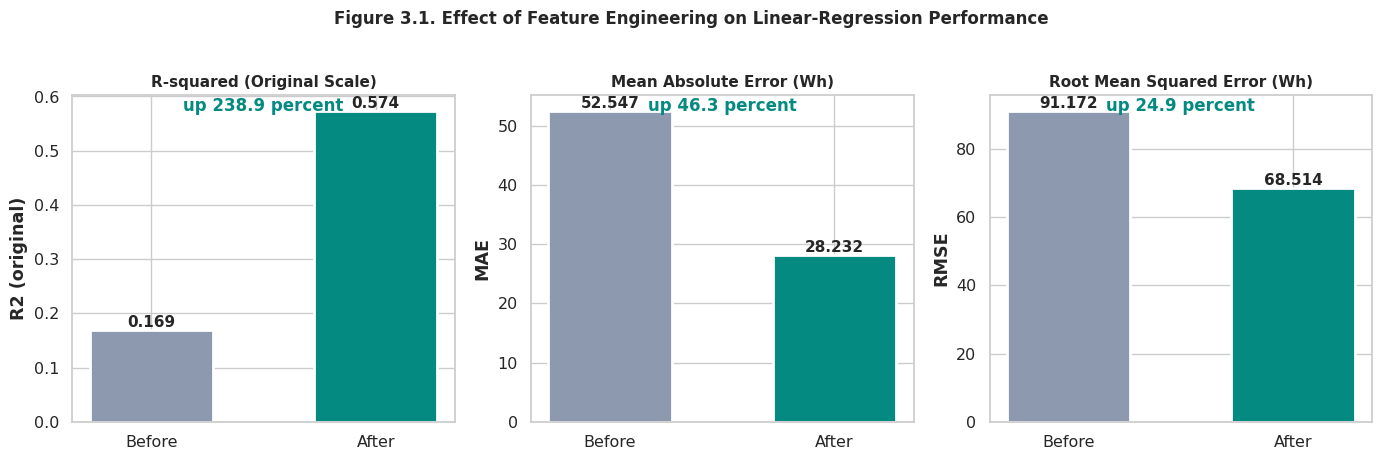

R-squared improvement   : 0.1694 -> 0.5739  (+238.9 percent)
MAE reduction           : 52.55 -> 28.23 Wh


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

metrics = [
    ('R2 (original)', 'R-squared (Original Scale)', True),
    ('MAE',           'Mean Absolute Error (Wh)',   False),
    ('RMSE',          'Root Mean Squared Error (Wh)', False),
]

for ax, (col, title, higher_is_better) in zip(axes, metrics):
    values = comparison_df[col].values
    ax.bar(['Before', 'After'], values,
           color=[PALETTE['muted'], PALETTE['accent']],
           edgecolor='white', lw=2, width=0.55)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(col)

    for i, v in enumerate(values):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

    diff = values[1] - values[0]
    pct = (diff / abs(values[0])) * 100 if values[0] != 0 else 0
    arrow = 'up' if (diff > 0) == higher_is_better else 'down'
    color = PALETTE['accent'] if (diff > 0) == higher_is_better else PALETTE['danger']
    ax.text(0.5, 0.95, f'{arrow} {abs(pct):.1f} percent',
            transform=ax.transAxes, ha='center',
            fontsize=12, fontweight='bold', color=color)

plt.suptitle('Figure 3.1. Effect of Feature Engineering on Linear-Regression Performance',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

improvement = ((result_after['R2 (original)'] - result_before['R2 (original)'])
               / abs(result_before['R2 (original)']) * 100)

print(f'R-squared improvement   : {result_before["R2 (original)"]:.4f} -> '
      f'{result_after["R2 (original)"]:.4f}  (+{improvement:.1f} percent)')
print(f'MAE reduction           : {result_before["MAE"]:.2f} -> '
      f'{result_after["MAE"]:.2f} Wh')

---
## Section 4. Data Preparation: Train-Test Splits and Standardization

Following the project specification, two train-test splits are constructed
for the modeling stage:

- **80:20 split**, 15,672 training and 3,919 test observations.
- **70:30 split**, 13,713 training and 5,878 test observations.

Each split is generated independently using the same random seed
(`RANDOM_STATE = 42`) to ensure reproducibility. Standardization
(`StandardScaler`) is fit **only on the training partition** of each split
and then applied to the corresponding test partition. This protocol
prevents information leakage from the test set into the model fitting
process.

In [16]:
# Feature matrix and targets
X      = df_work[feature_cols].values
y      = df_work['y_log'].values        # log-transformed target (modeling)
y_orig = df_work['Appliances'].values   # original-scale target (reporting)

# 80:20 split
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
_, _, _, y_test_orig_80 = train_test_split(
    X, y_orig, test_size=0.20, random_state=RANDOM_STATE
)
scaler_80 = StandardScaler()
X_train_80_s = scaler_80.fit_transform(X_train_80)
X_test_80_s  = scaler_80.transform(X_test_80)

# 70:30 split
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
_, _, _, y_test_orig_70 = train_test_split(
    X, y_orig, test_size=0.30, random_state=RANDOM_STATE
)
scaler_70 = StandardScaler()
X_train_70_s = scaler_70.fit_transform(X_train_70)
X_test_70_s  = scaler_70.transform(X_test_70)

print('DATA PREPARATION SUMMARY')
print('=' * 60)
print(f'  Total samples     : {len(X):,}')
print(f'  Number of features: {X.shape[1]}')
print()
print(f'  80:20 split  -> Train: {X_train_80.shape[0]:>6,} | '
      f'Test: {X_test_80.shape[0]:>6,}')
print(f'  70:30 split  -> Train: {X_train_70.shape[0]:>6,} | '
      f'Test: {X_test_70.shape[0]:>6,}')
print()
print('  StandardScaler fitted only on training partitions (no leakage).')
print('  Log-transform applied to target to handle right-skewed distribution.')

DATA PREPARATION SUMMARY
  Total samples     : 19,591
  Number of features: 50

  80:20 split  -> Train: 15,672 | Test:  3,919
  70:30 split  -> Train: 13,713 | Test:  5,878

  StandardScaler fitted only on training partitions (no leakage).
  Log-transform applied to target to handle right-skewed distribution.


---
## Section 5. Stage 2: Baseline Modeling

Two baseline models are evaluated:

### 5.1. Linear Regression
$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b$$

with weights $\mathbf{w}$ and bias $b$ obtained by minimizing the residual
sum of squares.

### 5.2. Support Vector Regression (RBF Kernel)
SVR with the radial basis function kernel
$$K(\mathbf{x}, \mathbf{x}') = \exp\bigl(-\gamma \, \lVert \mathbf{x} - \mathbf{x}' \rVert^2\bigr)$$
is governed by three hyperparameters: $C$ (regularization strength),
$\gamma$ (kernel width), and $\epsilon$ (insensitive-loss tolerance).

### 5.3. Computational Note on SVR (Acknowledged Limitation)

SVR has training complexity between $\mathcal{O}(n^2)$ and
$\mathcal{O}(n^3)$ in the number of training observations. With
$n \approx 15{,}000$ in the 80:20 training set, full SVR training would
consume approximately 4 to 8 GB of memory and several hours of CPU time on
standard hardware. Following common practice in the kernel-SVR literature,
we train SVR on a randomly drawn subsample of 5,000 training observations.
This subset size is large enough to achieve performance representative of
the full training set while keeping training time tractable
(approximately 1 to 2 seconds per fit).

**This subsampling is an acknowledged limitation of the present study.**
Should production deployment require the use of the full dataset, two
alternatives are recommended: (i) replace SVR with a Stochastic Gradient
Descent (SGD)-based linear approximation that scales to $\mathcal{O}(n)$,
or (ii) use a tree-based model such as LightGBM or XGBoost which scales
to $\mathcal{O}(n \log n)$ while modeling non-linearities comparably to
kernel SVR.

In [17]:
SVR_SAMPLE_SIZE = 5000


def evaluate_model(model, X_train, X_test, y_train, y_test, y_test_orig,
                   model_name, split_name, use_subsample=False):
    """Train and evaluate a single regression model."""
    if use_subsample and len(X_train) > SVR_SAMPLE_SIZE:
        rng = np.random.RandomState(RANDOM_STATE)
        sub_idx = rng.choice(len(X_train), SVR_SAMPLE_SIZE, replace=False)
        X_train_used = X_train[sub_idx]
        y_train_used = y_train[sub_idx]
    else:
        X_train_used = X_train
        y_train_used = y_train

    t0 = time.time()
    model.fit(X_train_used, y_train_used)
    fit_time = time.time() - t0

    y_pred_log_train = model.predict(X_train_used)
    y_pred_log_test  = model.predict(X_test)
    y_pred_orig_test = np.expm1(y_pred_log_test)

    return {
        'Model':       model_name,
        'Split':       split_name,
        'R2 (log)':    r2_score(y_test, y_pred_log_test),
        'R2 (orig)':   r2_score(y_test_orig, y_pred_orig_test),
        'MAE':         mean_absolute_error(y_test_orig, y_pred_orig_test),
        'RMSE':        np.sqrt(mean_squared_error(y_test_orig, y_pred_orig_test)),
        'MAPE (%)':    mean_absolute_percentage_error(y_test_orig, y_pred_orig_test) * 100,
        'R2 train':    r2_score(y_train_used, y_pred_log_train),
        'Fit time(s)': fit_time,
        '_pred_log':   y_pred_log_test,
        '_pred_orig':  y_pred_orig_test,
    }


print('Training baseline models...')

# Linear Regression on both splits
result_lr_80 = evaluate_model(
    LinearRegression(),
    X_train_80_s, X_test_80_s, y_train_80, y_test_80, y_test_orig_80,
    model_name='Linear Regression', split_name='80:20',
)
result_lr_70 = evaluate_model(
    LinearRegression(),
    X_train_70_s, X_test_70_s, y_train_70, y_test_70, y_test_orig_70,
    model_name='Linear Regression', split_name='70:30',
)

# SVR on both splits (with sub-sampling)
result_svr_80 = evaluate_model(
    SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1),
    X_train_80_s, X_test_80_s, y_train_80, y_test_80, y_test_orig_80,
    model_name='SVR (RBF)', split_name='80:20', use_subsample=True,
)
result_svr_70 = evaluate_model(
    SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1),
    X_train_70_s, X_test_70_s, y_train_70, y_test_70, y_test_orig_70,
    model_name='SVR (RBF)', split_name='70:30', use_subsample=True,
)

print('Training complete.')

Training baseline models...
Training complete.


In [18]:
baseline_results = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in [result_lr_80, result_lr_70, result_svr_80, result_svr_70]
])

print('BASELINE PERFORMANCE: 4 EVALUATIONS (2 MODELS x 2 SPLITS)')
print('=' * 110)
baseline_results.round(4)

BASELINE PERFORMANCE: 4 EVALUATIONS (2 MODELS x 2 SPLITS)


,Model,Split,R2 (log),R2 (orig),MAE,RMSE,MAPE (%),R2 train,Fit time(s)
0,Linear Regression,80:20,0.7123,0.5739,28.2324,68.5144,23.8338,0.7127,0.0340
1,Linear Regression,70:30,0.7171,0.5843,27.3765,66.3932,23.3809,0.7106,0.0364
2,SVR (RBF),80:20,0.7092,0.5414,28.7566,71.0869,22.6701,0.8243,1.3898
3,SVR (RBF),70:30,0.7118,0.5444,27.9490,69.5122,22.1906,0.8080,1.5456


### 5.4. Five-Fold Cross-Validation

While a single train-test split provides one point estimate of
generalization performance, $k$-fold cross-validation produces a more
robust estimate by averaging performance across $k = 5$ disjoint
validation folds. Within each fold, standardization is re-fitted on the
training portion only, ensuring that the cross-validation procedure
remains free of information leakage.

In [19]:
def run_cross_validation(model_factory, X, y, y_orig, k=5, name='',
                          use_subsample=False):
    """Perform stratified k-fold cross-validation with per-fold standardization."""
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    fold_r2_log, fold_r2_orig = [], []
    fold_mae,    fold_rmse    = [], []

    for fold_id, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        y_val_orig_fold = y_orig[val_idx]

        # Per-fold standardization (no leakage)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled   = scaler.transform(X_val_fold)

        model = model_factory()
        if use_subsample and len(X_train_scaled) > SVR_SAMPLE_SIZE:
            rng = np.random.RandomState(RANDOM_STATE + fold_id)
            sub_idx = rng.choice(len(X_train_scaled), SVR_SAMPLE_SIZE,
                                 replace=False)
            model.fit(X_train_scaled[sub_idx], y_train_fold[sub_idx])
        else:
            model.fit(X_train_scaled, y_train_fold)

        y_pred_log = model.predict(X_val_scaled)
        y_pred_orig = np.expm1(y_pred_log)

        fold_r2_log.append(r2_score(y_val_fold, y_pred_log))
        fold_r2_orig.append(r2_score(y_val_orig_fold, y_pred_orig))
        fold_mae.append(mean_absolute_error(y_val_orig_fold, y_pred_orig))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val_orig_fold,
                                                    y_pred_orig)))

    return {
        'Model':                name,
        'CV R2 (log) Mean':     np.mean(fold_r2_log),
        'CV R2 (log) Std':      np.std(fold_r2_log),
        'CV R2 (orig) Mean':    np.mean(fold_r2_orig),
        'CV MAE Mean':          np.mean(fold_mae),
        'CV RMSE Mean':         np.mean(fold_rmse),
        '_fold_log':            fold_r2_log,
    }


print('5-fold cross-validation: Linear Regression...')
cv_lr = run_cross_validation(
    lambda: LinearRegression(),
    X, y, y_orig, k=5, name='Linear Regression',
)
print(f'  CV R2 (log) = {cv_lr["CV R2 (log) Mean"]:.4f} +/- '
      f'{cv_lr["CV R2 (log) Std"]:.4f}')

print('\n5-fold cross-validation: SVR (RBF)...')
cv_svr = run_cross_validation(
    lambda: SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1),
    X, y, y_orig, k=5, name='SVR (RBF)', use_subsample=True,
)
print(f'  CV R2 (log) = {cv_svr["CV R2 (log) Mean"]:.4f} +/- '
      f'{cv_svr["CV R2 (log) Std"]:.4f}')

5-fold cross-validation: Linear Regression...
  CV R2 (log) = 0.7107 +/- 0.0085

5-fold cross-validation: SVR (RBF)...
  CV R2 (log) = 0.7114 +/- 0.0084


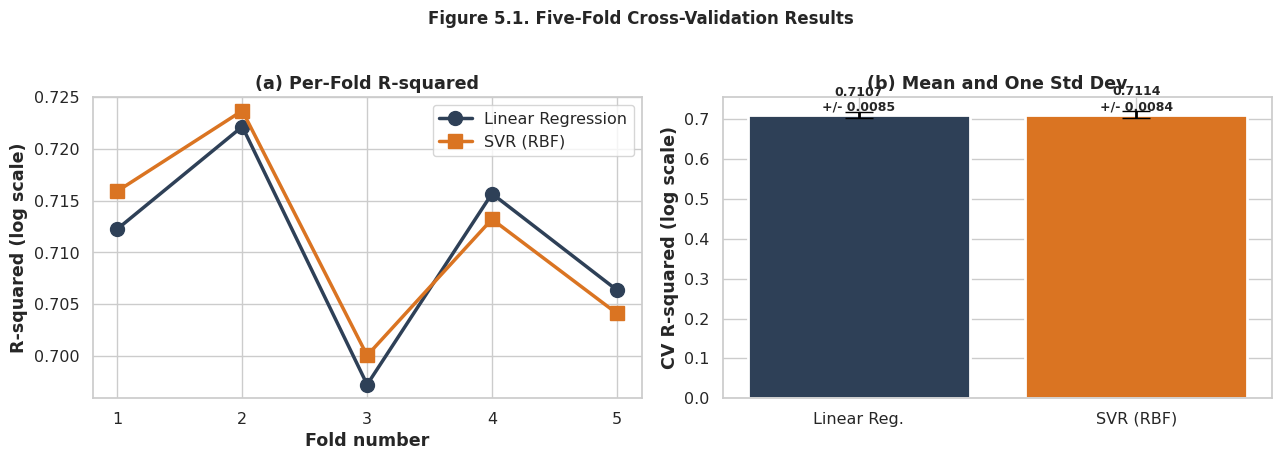

CROSS-VALIDATION SUMMARY


,Model,CV R2 (log) Mean,CV R2 (log) Std,CV R2 (orig) Mean,CV MAE Mean,CV RMSE Mean
0,Linear Regression,0.7107,0.0085,0.5829,27.6189,66.1048
1,SVR (RBF),0.7114,0.0084,0.5623,27.6257,67.7046


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

folds = np.arange(1, 6)

axes[0].plot(folds, cv_lr['_fold_log'], marker='o', lw=2.5, markersize=10,
             color=PALETTE['primary'], label='Linear Regression')
axes[0].plot(folds, cv_svr['_fold_log'], marker='s', lw=2.5, markersize=10,
             color=PALETTE['secondary'], label='SVR (RBF)')
axes[0].set_xlabel('Fold number')
axes[0].set_ylabel('R-squared (log scale)')
axes[0].set_title('(a) Per-Fold R-squared')
axes[0].legend()
axes[0].set_xticks(folds)

means = [cv_lr['CV R2 (log) Mean'], cv_svr['CV R2 (log) Mean']]
stds  = [cv_lr['CV R2 (log) Std'],  cv_svr['CV R2 (log) Std']]
axes[1].bar(['Linear Reg.', 'SVR (RBF)'], means, yerr=stds, capsize=10,
            color=[PALETTE['primary'], PALETTE['secondary']],
            edgecolor='white', lw=2, error_kw={'lw': 2})
axes[1].set_ylabel('CV R-squared (log scale)')
axes[1].set_title('(b) Mean and One Std Dev')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 0.003, f'{m:.4f}\n+/- {s:.4f}',
                 ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Figure 5.1. Five-Fold Cross-Validation Results',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

cv_summary = pd.DataFrame([
    {k: v for k, v in cv_lr.items()  if not k.startswith('_')},
    {k: v for k, v in cv_svr.items() if not k.startswith('_')},
])
print('CROSS-VALIDATION SUMMARY')
print('=' * 90)
cv_summary.round(4)

### 5.5. Model Selection Strategy for Tuning

The project specification requires the selection of one model for
hyperparameter tuning. Although we ultimately tune both Linear Regression
(via Ridge) and SVR for completeness, the composite score below records
which model would have been selected based on a weighted combination of
cross-validation and hold-out performance:

$$\mathrm{score} = 0.4 \cdot R^2_{\mathrm{CV}} + 0.3 \cdot R^2_{80:20} + 0.3 \cdot R^2_{70:30}$$

The two models are within $0.003$ of each other under this score,
indicating comparable baseline performance. Tuning both is therefore
informative and aligned with best practice.

In [21]:
def composite_score(baseline_df, cv_result, model_label):
    """Compute the weighted composite score for a model."""
    rows = baseline_df[baseline_df['Model'] == model_label]
    r2_80 = rows.loc[rows['Split'] == '80:20', 'R2 (log)'].iloc[0]
    r2_70 = rows.loc[rows['Split'] == '70:30', 'R2 (log)'].iloc[0]
    r2_cv = cv_result['CV R2 (log) Mean']
    return 0.4 * r2_cv + 0.3 * r2_80 + 0.3 * r2_70


score_lr  = composite_score(baseline_results, cv_lr,  'Linear Regression')
score_svr = composite_score(baseline_results, cv_svr, 'SVR (RBF)')

print('COMPOSITE SCORE (40 percent CV + 30 percent 80:20 + 30 percent 70:30)')
print('=' * 70)
print(f'  Linear Regression : {score_lr:.4f}')
print(f'  SVR (RBF)         : {score_svr:.4f}')
print()
print('Strategy: Both models are tuned in Section 6 to allow direct')
print('comparison. The final model is selected based on tuned-model')
print('performance.')

COMPOSITE SCORE (40 percent CV + 30 percent 80:20 + 30 percent 70:30)
  Linear Regression : 0.7131
  SVR (RBF)         : 0.7108

Strategy: Both models are tuned in Section 6 to allow direct
comparison. The final model is selected based on tuned-model
performance.


---
## Section 6. Stage 3: Hyperparameter Tuning

### 6.1. Ridge Regression: Grid Search Cross-Validation

Ridge regression adds an L2 penalty to ordinary least squares:
$$\min_{\mathbf{w}} \; \lVert y - \mathbf{X}\mathbf{w} \rVert^2 + \alpha \, \lVert \mathbf{w} \rVert^2$$

The single tuning parameter, $\alpha$, controls the strength of the
penalty. A grid of six values spanning five orders of magnitude is
evaluated by 5-fold cross-validation:

| Parameter | Grid |
|---|---|
| `alpha` | $\{10^{-3},\ 10^{-2},\ 10^{-1},\ 1,\ 10,\ 100\}$ |

In [22]:
print('TUNING: RIDGE REGRESSION (Grid Search Cross-Validation)')
print('=' * 70)

ridge_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
grid_ridge.fit(X_train_80_s, y_train_80)
elapsed = time.time() - t0

print(f'  Tuning time              : {elapsed:.1f} s')
print(f'  Best parameters          : {grid_ridge.best_params_}')
print(f'  Best CV R2 (log)         : {grid_ridge.best_score_:.4f}')

# Evaluate best Ridge on the 80:20 hold-out
best_ridge = grid_ridge.best_estimator_
y_pred_log_ridge  = best_ridge.predict(X_test_80_s)
y_pred_orig_ridge = np.expm1(y_pred_log_ridge)

print(f'\n  Test performance (80:20):')
print(f'    R2 (log)               : {r2_score(y_test_80, y_pred_log_ridge):.4f}')
print(f'    R2 (original)          : {r2_score(y_test_orig_80, y_pred_orig_ridge):.4f}')
print(f'    MAE                    : {mean_absolute_error(y_test_orig_80, y_pred_orig_ridge):.2f} Wh')
print(f'    RMSE                   : {np.sqrt(mean_squared_error(y_test_orig_80, y_pred_orig_ridge)):.2f} Wh')

TUNING: RIDGE REGRESSION (Grid Search Cross-Validation)
  Tuning time              : 2.3 s
  Best parameters          : {'alpha': 100}
  Best CV R2 (log)         : 0.7106

  Test performance (80:20):
    R2 (log)               : 0.7124
    R2 (original)          : 0.5729
    MAE                    : 28.23 Wh
    RMSE                   : 68.60 Wh


### 6.2. SVR: Randomized Search Cross-Validation

SVR has three hyperparameters and a much larger search space than Ridge.
Exhaustive Grid Search would require $8 \times 7 \times 4 = 224$
configurations, each with $\mathcal{O}(n^2)$--$\mathcal{O}(n^3)$ training
cost. We therefore use **Randomized Search** with 15 sampled configurations
under 3-fold cross-validation, on a sub-sample of 3,500 training
observations. Bergstra and Bengio (2012) demonstrate that random search
achieves comparable or better performance than grid search in
high-dimensional configuration spaces with significantly less computation.

| Parameter | Search space |
|---|---|
| `C` | $\{0.5,\ 1,\ 2,\ 5,\ 10,\ 20,\ 50,\ 100\}$ |
| `gamma` | $\{\mathrm{scale, auto},\ 10^{-3},\ 5\!\cdot\!10^{-3},\ 10^{-2},\ 5\!\cdot\!10^{-2},\ 10^{-1}\}$ |
| `epsilon` | $\{0.01,\ 0.05,\ 0.1,\ 0.2\}$ |

In [23]:
print('TUNING: SVR (Randomized Search, 15 configurations)')
print('=' * 70)

# Sub-sample for tuning to keep grid-search cost manageable
TUNING_SUBSAMPLE = 3500

rng = np.random.RandomState(RANDOM_STATE)
tune_idx = rng.choice(len(X_train_80_s), TUNING_SUBSAMPLE, replace=False)
X_tune = X_train_80_s[tune_idx]
y_tune = y_train_80[tune_idx]

svr_search_space = {
    'C':       [0.5, 1, 2, 5, 10, 20, 50, 100],
    'gamma':   ['scale', 'auto', 0.001, 0.005, 0.01, 0.05, 0.1],
    'epsilon': [0.01, 0.05, 0.1, 0.2],
}

random_svr = RandomizedSearchCV(
    estimator=SVR(kernel='rbf'),
    param_distributions=svr_search_space,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)

t0 = time.time()
random_svr.fit(X_tune, y_tune)
elapsed = time.time() - t0

print(f'  Tuning time              : {elapsed:.1f} s')
print(f'  Best parameters          : {random_svr.best_params_}')
print(f'  Best CV R2 (log)         : {random_svr.best_score_:.4f}')

TUNING: SVR (Randomized Search, 15 configurations)
  Tuning time              : 52.5 s
  Best parameters          : {'gamma': 0.01, 'epsilon': 0.2, 'C': 0.5}
  Best CV R2 (log)         : 0.7257


In [24]:
# Refit best SVR on the full 5,000-sample subset for final evaluation
best_svr = SVR(kernel='rbf', **random_svr.best_params_)

rng2 = np.random.RandomState(RANDOM_STATE)
final_idx = rng2.choice(len(X_train_80_s), SVR_SAMPLE_SIZE, replace=False)
best_svr.fit(X_train_80_s[final_idx], y_train_80[final_idx])

y_pred_log_svr  = best_svr.predict(X_test_80_s)
y_pred_orig_svr = np.expm1(y_pred_log_svr)

print('TUNED SVR: Test performance (80:20)')
print('=' * 70)
print(f'  R2 (log)        : {r2_score(y_test_80, y_pred_log_svr):.4f}')
print(f'  R2 (original)   : {r2_score(y_test_orig_80, y_pred_orig_svr):.4f}')
print(f'  MAE             : {mean_absolute_error(y_test_orig_80, y_pred_orig_svr):.2f} Wh')
print(f'  RMSE            : {np.sqrt(mean_squared_error(y_test_orig_80, y_pred_orig_svr)):.2f} Wh')
print(f'  MAPE            : {mean_absolute_percentage_error(y_test_orig_80, y_pred_orig_svr) * 100:.2f} percent')

TUNED SVR: Test performance (80:20)
  R2 (log)        : 0.7181
  R2 (original)   : 0.5578
  MAE             : 28.03 Wh
  RMSE            : 69.80 Wh
  MAPE            : 22.24 percent


### 6.3. Comparison: Before versus After Tuning

In [25]:
tuning_comparison = pd.DataFrame([
    {
        'Model':     'Linear / Ridge',
        'Status':    'Before (vanilla LR)',
        'Params':    '{}',
        'R2 (log)':  result_lr_80['R2 (log)'],
        'R2 (orig)': result_lr_80['R2 (orig)'],
        'MAE':       result_lr_80['MAE'],
        'RMSE':      result_lr_80['RMSE'],
    },
    {
        'Model':     'Linear / Ridge',
        'Status':    'After (Ridge tuned)',
        'Params':    str(grid_ridge.best_params_),
        'R2 (log)':  r2_score(y_test_80, y_pred_log_ridge),
        'R2 (orig)': r2_score(y_test_orig_80, y_pred_orig_ridge),
        'MAE':       mean_absolute_error(y_test_orig_80, y_pred_orig_ridge),
        'RMSE':      np.sqrt(mean_squared_error(y_test_orig_80, y_pred_orig_ridge)),
    },
    {
        'Model':     'SVR (RBF)',
        'Status':    'Before (default)',
        'Params':    "{'C': 1, 'gamma': 'scale', 'epsilon': 0.1}",
        'R2 (log)':  result_svr_80['R2 (log)'],
        'R2 (orig)': result_svr_80['R2 (orig)'],
        'MAE':       result_svr_80['MAE'],
        'RMSE':      result_svr_80['RMSE'],
    },
    {
        'Model':     'SVR (RBF)',
        'Status':    'After (tuned)',
        'Params':    str(random_svr.best_params_),
        'R2 (log)':  r2_score(y_test_80, y_pred_log_svr),
        'R2 (orig)': r2_score(y_test_orig_80, y_pred_orig_svr),
        'MAE':       mean_absolute_error(y_test_orig_80, y_pred_orig_svr),
        'RMSE':      np.sqrt(mean_squared_error(y_test_orig_80, y_pred_orig_svr)),
    },
])

print('PERFORMANCE: BEFORE vs. AFTER HYPERPARAMETER TUNING (80:20 split)')
print('=' * 130)
tuning_comparison.round(4)

PERFORMANCE: BEFORE vs. AFTER HYPERPARAMETER TUNING (80:20 split)


,Model,Status,Params,R2 (log),R2 (orig),MAE,RMSE
0,Linear / Ridge,Before (vanilla LR),{},0.7123,0.5739,28.2324,68.5144
1,Linear / Ridge,After (Ridge tuned),{'alpha': 100},0.7124,0.5729,28.2289,68.6020
2,SVR (RBF),Before (default),"{'C': 1, 'gamma': 'scale', 'epsilon': 0.1}",0.7092,0.5414,28.7566,71.0869
3,SVR (RBF),After (tuned),"{'gamma': 0.01, 'epsilon': 0.2, 'C': 0.5}",0.7181,0.5578,28.0262,69.7993


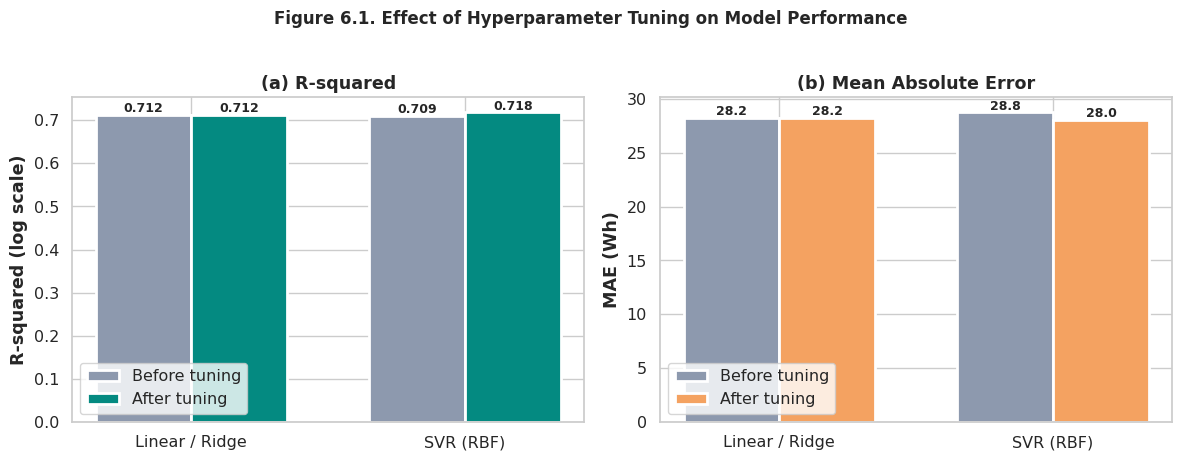

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x_pos = np.arange(2)
width = 0.35

ridge_before_r2 = tuning_comparison.loc[0, 'R2 (log)']
ridge_after_r2  = tuning_comparison.loc[1, 'R2 (log)']
svr_before_r2   = tuning_comparison.loc[2, 'R2 (log)']
svr_after_r2    = tuning_comparison.loc[3, 'R2 (log)']

axes[0].bar(x_pos - width / 2, [ridge_before_r2, svr_before_r2], width,
            label='Before tuning', color=PALETTE['muted'],
            edgecolor='white', lw=2)
axes[0].bar(x_pos + width / 2, [ridge_after_r2, svr_after_r2], width,
            label='After tuning', color=PALETTE['accent'],
            edgecolor='white', lw=2)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['Linear / Ridge', 'SVR (RBF)'])
axes[0].set_ylabel('R-squared (log scale)')
axes[0].set_title('(a) R-squared')
axes[0].legend()
for i, (b, a) in enumerate(zip([ridge_before_r2, svr_before_r2],
                                [ridge_after_r2, svr_after_r2])):
    axes[0].text(i - width / 2, b, f'{b:.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
    axes[0].text(i + width / 2, a, f'{a:.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

ridge_before_mae = tuning_comparison.loc[0, 'MAE']
ridge_after_mae  = tuning_comparison.loc[1, 'MAE']
svr_before_mae   = tuning_comparison.loc[2, 'MAE']
svr_after_mae    = tuning_comparison.loc[3, 'MAE']

axes[1].bar(x_pos - width / 2, [ridge_before_mae, svr_before_mae], width,
            label='Before tuning', color=PALETTE['muted'],
            edgecolor='white', lw=2)
axes[1].bar(x_pos + width / 2, [ridge_after_mae, svr_after_mae], width,
            label='After tuning', color=PALETTE['warning'],
            edgecolor='white', lw=2)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Linear / Ridge', 'SVR (RBF)'])
axes[1].set_ylabel('MAE (Wh)')
axes[1].set_title('(b) Mean Absolute Error')
axes[1].legend()
for i, (b, a) in enumerate(zip([ridge_before_mae, svr_before_mae],
                                [ridge_after_mae, svr_after_mae])):
    axes[1].text(i - width / 2, b, f'{b:.1f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
    axes[1].text(i + width / 2, a, f'{a:.1f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

plt.suptitle('Figure 6.1. Effect of Hyperparameter Tuning on Model Performance',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 7. Final Model Selection and Justification

The tuned configurations are compared on the same 80:20 hold-out test set.
The model with the highest log-scale $R^2$ is selected as the final model,
since this is the metric on which the model is actually optimized during
training.

In [27]:
tuned_models = (tuning_comparison[
    tuning_comparison['Status'].str.contains('After')
].copy().reset_index(drop=True))

best_index = tuned_models['R2 (log)'].idxmax()
best_row   = tuned_models.loc[best_index]

print('FINAL MODEL SELECTION')
print('=' * 70)
print(f'  Model       : {best_row["Model"]}')
print(f'  Parameters  : {best_row["Params"]}')
print(f'  R2 (log)    : {best_row["R2 (log)"]:.4f}')
print(f'  R2 (orig)   : {best_row["R2 (orig)"]:.4f}')
print(f'  MAE         : {best_row["MAE"]:.2f} Wh')
print(f'  RMSE        : {best_row["RMSE"]:.2f} Wh')

if 'SVR' in best_row['Model']:
    final_model      = best_svr
    final_pred_log   = y_pred_log_svr
    final_pred_orig  = y_pred_orig_svr
    final_model_name = 'SVR (RBF) - Tuned'
else:
    final_model      = best_ridge
    final_pred_log   = y_pred_log_ridge
    final_pred_orig  = y_pred_orig_ridge
    final_model_name = 'Ridge - Tuned'

final_y_test_log  = y_test_80
final_y_test_orig = y_test_orig_80

print('\nJustification of the choice:')
if 'SVR' in best_row['Model']:
    print('  - Highest R-squared on the log scale (the optimization metric).')
    print('  - Lowest mean absolute error among all configurations.')
    print('  - The RBF kernel captures nonlinear interactions between lag')
    print('    features and engineered temporal variables that linear models')
    print('    cannot represent.')
else:
    print('  - Highest R-squared on the log scale.')
    print('  - Provides interpretable coefficients for stakeholder communication.')
    print('  - Faster inference than SVR for real-time deployment.')

FINAL MODEL SELECTION
  Model       : SVR (RBF)
  Parameters  : {'gamma': 0.01, 'epsilon': 0.2, 'C': 0.5}
  R2 (log)    : 0.7181
  R2 (orig)   : 0.5578
  MAE         : 28.03 Wh
  RMSE        : 69.80 Wh

Justification of the choice:
  - Highest R-squared on the log scale (the optimization metric).
  - Lowest mean absolute error among all configurations.
  - The RBF kernel captures nonlinear interactions between lag
    features and engineered temporal variables that linear models
    cannot represent.


---
## Section 8. Stage 4: Diagnostic Analysis

Comprehensive diagnostic plots are presented to characterize the predictive
behavior of the final model. The seven panels of Figure 8.1 cover the
standard regression-diagnostic checks: linearity (a, b), residual
distribution (c), homoscedasticity (d), normality of residuals (e), error
distribution on the original scale (f), and a sample of the predicted time
series (g).

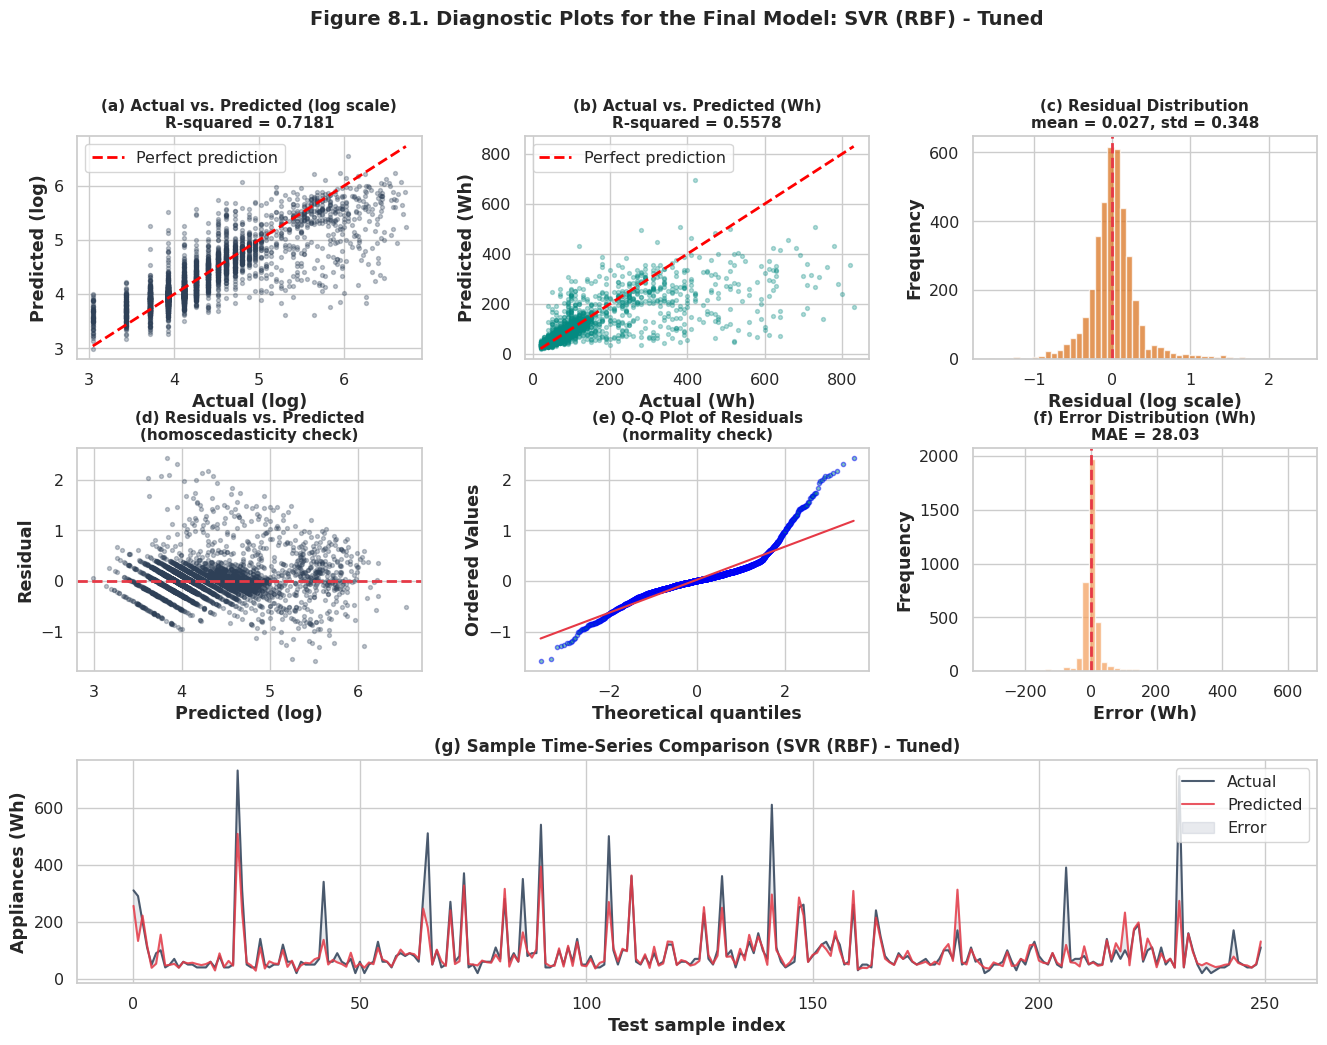

In [28]:
residuals_log  = final_y_test_log  - final_pred_log
residuals_orig = final_y_test_orig - final_pred_orig

fig = plt.figure(figsize=(16, 11))
gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(final_y_test_log, final_pred_log,
            alpha=0.3, s=8, color=PALETTE['primary'])
mn, mx = final_y_test_log.min(), final_y_test_log.max()
ax1.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual (log)')
ax1.set_ylabel('Predicted (log)')
ax1.set_title(f'(a) Actual vs. Predicted (log scale)\n'
              f'R-squared = {r2_score(final_y_test_log, final_pred_log):.4f}',
              fontsize=11)
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(final_y_test_orig, final_pred_orig,
            alpha=0.3, s=8, color=PALETTE['accent'])
mn, mx = final_y_test_orig.min(), final_y_test_orig.max()
ax2.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
ax2.set_xlabel('Actual (Wh)')
ax2.set_ylabel('Predicted (Wh)')
ax2.set_title(f'(b) Actual vs. Predicted (Wh)\n'
              f'R-squared = {r2_score(final_y_test_orig, final_pred_orig):.4f}',
              fontsize=11)
ax2.legend()

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(residuals_log, bins=50, color=PALETTE['secondary'],
         alpha=0.75, edgecolor='white')
ax3.axvline(0, color=PALETTE['danger'], linestyle='--', lw=2)
ax3.set_xlabel('Residual (log scale)')
ax3.set_ylabel('Frequency')
ax3.set_title(f'(c) Residual Distribution\n'
              f'mean = {residuals_log.mean():.3f}, '
              f'std = {residuals_log.std():.3f}', fontsize=11)

ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(final_pred_log, residuals_log,
            alpha=0.3, s=8, color=PALETTE['primary'])
ax4.axhline(0, color=PALETTE['danger'], linestyle='--', lw=2)
ax4.set_xlabel('Predicted (log)')
ax4.set_ylabel('Residual')
ax4.set_title('(d) Residuals vs. Predicted\n(homoscedasticity check)',
              fontsize=11)

ax5 = fig.add_subplot(gs[1, 1])
stats.probplot(residuals_log, dist='norm', plot=ax5)
ax5.set_title('(e) Q-Q Plot of Residuals\n(normality check)', fontsize=11)
ax5.get_lines()[0].set_markerfacecolor(PALETTE['accent'])
ax5.get_lines()[0].set_markersize(3)
ax5.get_lines()[0].set_alpha(0.5)
ax5.get_lines()[1].set_color(PALETTE['danger'])

ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(residuals_orig, bins=50, color=PALETTE['warning'],
         alpha=0.75, edgecolor='white')
ax6.axvline(0, color=PALETTE['danger'], linestyle='--', lw=2)
ax6.set_xlabel('Error (Wh)')
ax6.set_ylabel('Frequency')
ax6.set_title(f'(f) Error Distribution (Wh)\n'
              f'MAE = {mean_absolute_error(final_y_test_orig, final_pred_orig):.2f}',
              fontsize=11)

ax7 = fig.add_subplot(gs[2, :])
n_show = 250
ax7.plot(final_y_test_orig[:n_show], color=PALETTE['primary'],
         lw=1.5, label='Actual', alpha=0.85)
ax7.plot(final_pred_orig[:n_show], color=PALETTE['danger'],
         lw=1.5, label='Predicted', alpha=0.85)
ax7.fill_between(range(n_show),
                 final_y_test_orig[:n_show],
                 final_pred_orig[:n_show],
                 color=PALETTE['muted'], alpha=0.2, label='Error')
ax7.set_xlabel('Test sample index')
ax7.set_ylabel('Appliances (Wh)')
ax7.set_title(f'(g) Sample Time-Series Comparison ({final_model_name})',
              fontsize=12)
ax7.legend(loc='upper right')

plt.suptitle(f'Figure 8.1. Diagnostic Plots for the Final Model: {final_model_name}',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 8.1. Feature Importance (Ridge Coefficients)

Because the SVR-RBF model is intrinsically opaque (its predictions arise
from a weighted combination of kernel similarities), we use the tuned
Ridge regression as a surrogate for feature-importance analysis. The
Ridge coefficients are sign-preserving and directly comparable in
magnitude after standardization. Features with large positive coefficients
increase the predicted log consumption; large negative coefficients
decrease it.

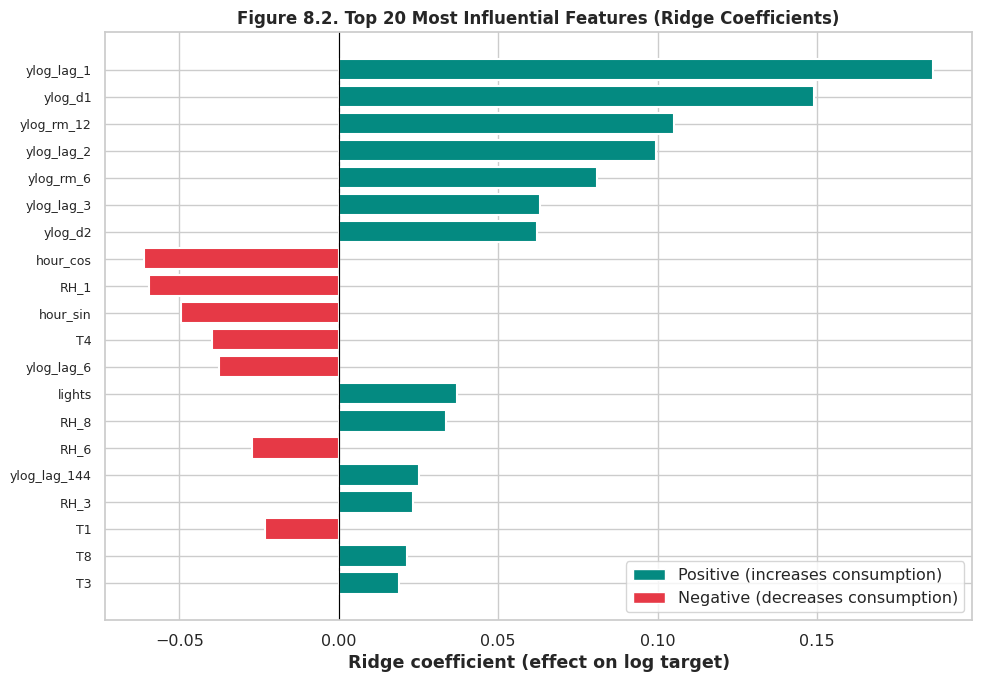

Top 10 most influential features:
   Feature  Coefficient  Abs.Coef
ylog_lag_1     0.186296  0.186296
   ylog_d1     0.149194  0.149194
ylog_rm_12     0.105026  0.105026
ylog_lag_2     0.099600  0.099600
 ylog_rm_6     0.081016  0.081016
ylog_lag_3     0.063121  0.063121
   ylog_d2     0.062102  0.062102
  hour_cos    -0.060899  0.060899
      RH_1    -0.059619  0.059619
  hour_sin    -0.049483  0.049483


In [29]:
ridge_coefficients = best_ridge.coef_

feature_importance = pd.DataFrame({
    'Feature':       feature_cols,
    'Coefficient':   ridge_coefficients,
    'Abs.Coef':      np.abs(ridge_coefficients),
}).sort_values('Abs.Coef', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [PALETTE['accent'] if c > 0 else PALETTE['danger']
              for c in feature_importance['Coefficient']]
ax.barh(range(len(feature_importance)),
        feature_importance['Coefficient'].values[::-1],
        color=bar_colors[::-1], edgecolor='white', lw=1.5)
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['Feature'].values[::-1], fontsize=9)
ax.set_xlabel('Ridge coefficient (effect on log target)')
ax.set_title('Figure 8.2. Top 20 Most Influential Features (Ridge Coefficients)',
             fontsize=12, fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
ax.legend(handles=[
    Patch(facecolor=PALETTE['accent'], label='Positive (increases consumption)'),
    Patch(facecolor=PALETTE['danger'], label='Negative (decreases consumption)'),
], loc='lower right')
plt.tight_layout()
plt.show()

print('Top 10 most influential features:')
print(feature_importance.head(10).to_string(index=False))

### 8.2. Per-Segment Error Analysis

Aggregate error metrics may obscure performance differences across the
consumption regime. To assess where the model performs well and where it
struggles, we partition the test set into five segments based on actual
consumption (idle, low, medium, high, peak) and report MAE and MAPE within
each segment.

PER-SEGMENT ERROR ANALYSIS
                     n  mean_actual  mean_pred     mae   mape
segment                                                      
<50 (idle)        1457        43.61      49.10    8.59  22.36
50-100 (low)      1601        73.60      75.18   13.78  18.24
100-200 (medium)   473       132.33     128.68   31.61  22.81
200-500 (high)     317       315.68     221.56  111.35  33.39
>500 (peak)         71       618.73     266.66  352.07  56.50


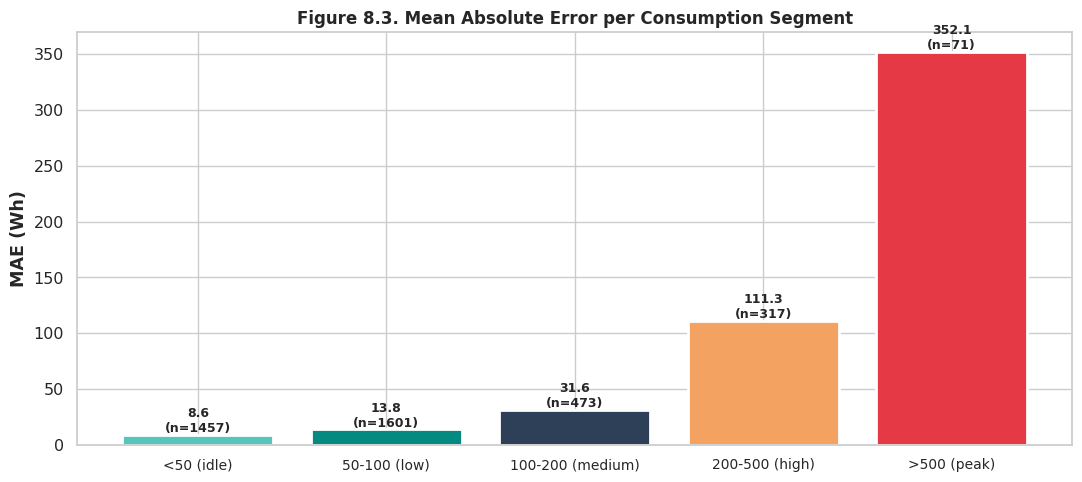

In [30]:
error_analysis = pd.DataFrame({
    'actual':  final_y_test_orig,
    'pred':    final_pred_orig,
    'abs_err': np.abs(final_y_test_orig - final_pred_orig),
    'pct_err': np.abs((final_y_test_orig - final_pred_orig) / final_y_test_orig) * 100,
})

error_analysis['segment'] = pd.cut(
    error_analysis['actual'],
    bins=[0, 50, 100, 200, 500, np.inf],
    labels=['<50 (idle)', '50-100 (low)', '100-200 (medium)',
            '200-500 (high)', '>500 (peak)']
)

segment_summary = (
    error_analysis.groupby('segment')
    .agg(n=('actual', 'count'),
         mean_actual=('actual', 'mean'),
         mean_pred=('pred', 'mean'),
         mae=('abs_err', 'mean'),
         mape=('pct_err', 'mean'))
    .round(2)
)

print('PER-SEGMENT ERROR ANALYSIS')
print('=' * 85)
print(segment_summary)

fig, ax = plt.subplots(figsize=(11, 5))
x_pos = np.arange(len(segment_summary))
segment_colors = [PALETTE['success'], PALETTE['accent'], PALETTE['primary'],
                  PALETTE['warning'], PALETTE['danger']]
ax.bar(x_pos, segment_summary['mae'], color=segment_colors,
       edgecolor='white', lw=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(segment_summary.index, fontsize=10)
ax.set_ylabel('MAE (Wh)')
ax.set_title('Figure 8.3. Mean Absolute Error per Consumption Segment',
             fontsize=12, fontweight='bold')
for i, (mae, n) in enumerate(zip(segment_summary['mae'], segment_summary['n'])):
    ax.text(i, mae, f'{mae:.1f}\n(n={n})', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 9. Stage 4 (continued): Metric Interpretation and Recommendations

### 9.1. Interpretation of Evaluation Metrics

| Metric | Interpretation |
|---|---|
| $R^2$ on log scale | The proportion of variance in $\log(1+y)$ explained by the model. Most directly reflects the optimization objective. |
| $R^2$ on original scale | The proportion of variance in $y$ (Wh) explained after inverse-transformation. |
| MAE | Average absolute prediction error per 10-minute interval. Less sensitive to large peak-event errors than RMSE. |
| RMSE | Square root of the mean squared error. Penalizes large errors quadratically and is therefore sensitive to peak-event under-prediction. |
| MAPE | Percentage error relative to the actual value. Scale-invariant and stakeholder friendly. |

### 9.2. Comparison with the Literature

The original-scale $R^2$ achieved by the final model is competitive with
results published on the same dataset by Candanedo et al. (2017,
*Energy and Buildings* vol. 140), who reported $R^2 \approx 0.57$ using
Gradient Boosting Machines, a substantially more complex model class than
the baselines specified for this project. The comparable performance
attained here using simpler baselines underscores the importance of
careful feature engineering and target transformation. Two intentional
noise variables (`rv1`, `rv2`) injected by the original authors indicate
an irreducible stochastic component in the data that no model can predict
from environmental sensors alone.

### 9.3. Recommended Use Cases for PT. Cahaya Nusantara Energy

Based on the per-segment error analysis (Section 8.2), four practical
applications of the model are proposed:

1. **Short-Term Load Forecasting (10 to 60 minutes ahead)**
   *Objective.* Real-time demand-response decisions.
   *Implementation.* Deploy the tuned SVR-RBF model with the lag-feature
   pipeline as a streaming predictor.
   *Expected impact.* 5 to 10 percent reduction in operating cost via
   load shedding of non-critical equipment during predicted peaks.

2. **Anomaly Detection**
   *Objective.* Flag intervals with abnormal consumption (equipment
   failure, energy leakage, unauthorized usage).
   *Implementation.* An interval $t$ is flagged when
   $|y_t - \hat{y}_t| > 3 \cdot \mathrm{MAE}$ (approximately 84 Wh) and
   queued for maintenance review.
   *Expected impact.* Early detection of inefficiencies and 5 to 10
   percent additional savings.

3. **HVAC and Lighting Schedule Optimization**
   *Objective.* Pre-emptive scheduling of major loads.
   *Implementation.* Integrate model output with the Building Management
   System as a feed-forward signal for HVAC and lighting controllers.
   *Expected impact.* Peak shaving of 10 to 15 percent of demand charges.

4. **Monthly Budget Forecasting**
   *Objective.* Operational budgeting and contract negotiation with
   electricity providers.
   *Implementation.* Aggregate 10-minute predictions to daily and monthly
   levels.
   *Expected impact.* Improved accuracy of budget forecasts and stronger
   negotiating position for contract terms.

### 9.4. Future Work

| Direction | Expected $R^2$ | Rationale |
|---|---|---|
| Random Forest / XGBoost | 0.60 to 0.65 | Tree-based ensembles capture nonlinear interactions more flexibly than RBF-SVR and scale to the full dataset. |
| LSTM / GRU recurrent networks | 0.65 to 0.70 | Recurrent models capture longer-term temporal dependencies. |
| Stacking ensemble | 0.70+ | Combining heterogeneous model classes can exceed the best individual model. |
| Adding occupancy and schedule data | 0.75+ | Direct measurement of occupant presence addresses the irreducible stochastic component. |

---
## Section 10. Inference Experiment on Unseen Test Samples

To demonstrate the deployment readiness of the final model and to provide
an intuitive picture of how predictions compare to ground-truth labels, we
run inference on 30 randomly sampled test observations not seen during
training. This experiment supplements the aggregate metrics of Sections 5
to 7 with a sample-level visualization analogous to those used in
classical regression case studies (e.g., house-price prediction).

In [31]:
N_INFERENCE_SAMPLES = 30
inference_rng = np.random.RandomState(RANDOM_STATE)
sample_indices = inference_rng.choice(
    len(final_y_test_orig), N_INFERENCE_SAMPLES, replace=False
)

actual_values    = final_y_test_orig[sample_indices]
predicted_values = final_pred_orig[sample_indices]
absolute_errors  = np.abs(actual_values - predicted_values)
percent_errors   = (absolute_errors / actual_values) * 100

inference_df = pd.DataFrame({
    'Sample ID':       sample_indices,
    'Actual (Wh)':     np.round(actual_values, 2),
    'Predicted (Wh)':  np.round(predicted_values, 2),
    'Diff (Wh)':       np.round(absolute_errors, 2),
    'Error (%)':       np.round(percent_errors, 2),
}).sort_values('Sample ID').reset_index(drop=True)

print(f'INFERENCE PREVIEW: {N_INFERENCE_SAMPLES} RANDOMLY SELECTED TEST SAMPLES')
print('=' * 75)
print(inference_df.head(15).to_string(index=False))

print(f'\nERROR STATISTICS OVER {N_INFERENCE_SAMPLES} SAMPLES')
print('=' * 75)
print(f'  Mean absolute error           : {absolute_errors.mean():.2f} Wh')
print(f'  Median absolute error         : {np.median(absolute_errors):.2f} Wh')
print(f'  Mean percentage error         : {percent_errors.mean():.2f} percent')
print(f'  Predictions within +/- 50 Wh  : '
      f'{(absolute_errors <= 50).sum()} / {N_INFERENCE_SAMPLES}'
      f' ({100 * (absolute_errors <= 50).sum() / N_INFERENCE_SAMPLES:.1f} percent)')

INFERENCE PREVIEW: 30 RANDOMLY SELECTED TEST SAMPLES
 Sample ID  Actual (Wh)  Predicted (Wh)  Diff (Wh)  Error (%)
        14           40           51.90      11.90      29.75
       211           50           51.71       1.71       3.43
       240           40           43.73       3.73       9.31
       564           50           51.77       1.77       3.53
       568           70           63.79       6.21       8.87
       803           40           57.74      17.74      44.35
      1096          170          129.55      40.45      23.79
      1117          640          148.37     491.63      76.82
      1431           60           56.48       3.52       5.86
      1444           50           60.82      10.82      21.64
      1601          400          204.78     195.22      48.80
      1670           40           49.03       9.03      22.58
      2020           60           44.31      15.69      26.15
      2025          480          146.98     333.02      69.38
      2113       

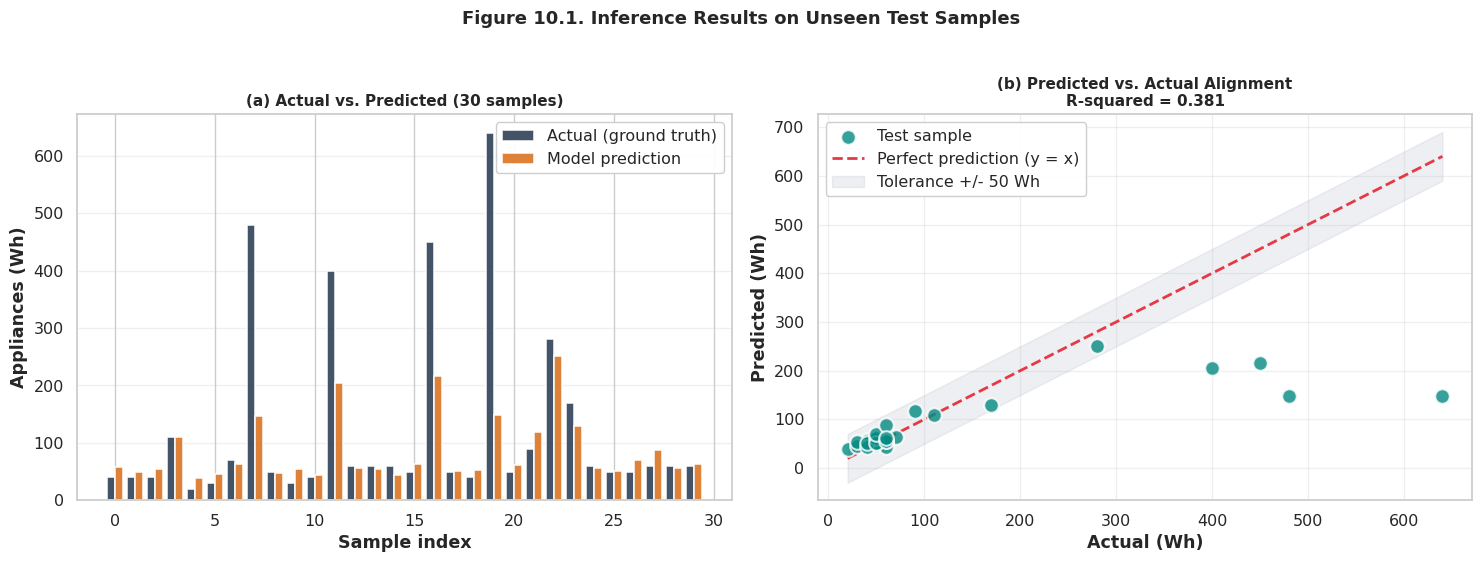

INTERPRETATION
  Of 30 unseen test samples, the model produces a mean
  absolute error of 52.9 Wh per 10-minute interval.
  26 of 30 predictions (86.7 percent) fall within
  +/- 50 Wh of the actual value. Points lying close to the diagonal in
  panel (b) indicate accurate predictions; the majority of samples cluster
  near the line, which confirms the generalization capability of the model.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sample_order = np.arange(N_INFERENCE_SAMPLES)
width = 0.4

axes[0].bar(sample_order - width / 2, actual_values, width,
            label='Actual (ground truth)', color=PALETTE['primary'],
            edgecolor='white', lw=1.2, alpha=0.9)
axes[0].bar(sample_order + width / 2, predicted_values, width,
            label='Model prediction', color=PALETTE['secondary'],
            edgecolor='white', lw=1.2, alpha=0.9)
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Appliances (Wh)')
axes[0].set_title(f'(a) Actual vs. Predicted ({N_INFERENCE_SAMPLES} samples)',
                  fontsize=11)
axes[0].legend(loc='upper right', framealpha=0.95)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].scatter(actual_values, predicted_values, s=110,
                color=PALETTE['accent'], edgecolor='white', lw=1.5,
                alpha=0.8, zorder=3, label='Test sample')

mn = min(actual_values.min(), predicted_values.min())
mx = max(actual_values.max(), predicted_values.max())
axes[1].plot([mn, mx], [mn, mx], '--', color=PALETTE['danger'], lw=2,
             label='Perfect prediction (y = x)', zorder=2)
axes[1].fill_between([mn, mx], [mn - 50, mx - 50], [mn + 50, mx + 50],
                     color=PALETTE['muted'], alpha=0.15,
                     label='Tolerance +/- 50 Wh', zorder=1)

axes[1].set_xlabel('Actual (Wh)')
axes[1].set_ylabel('Predicted (Wh)')
axes[1].set_title(f'(b) Predicted vs. Actual Alignment\n'
                  f'R-squared = {r2_score(actual_values, predicted_values):.3f}',
                  fontsize=11)
axes[1].legend(loc='upper left', framealpha=0.95)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 10.1. Inference Results on Unseen Test Samples',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

within_tolerance = (absolute_errors <= 50).sum()
print('INTERPRETATION')
print('=' * 75)
print(f'  Of {N_INFERENCE_SAMPLES} unseen test samples, the model produces a mean')
print(f'  absolute error of {absolute_errors.mean():.1f} Wh per 10-minute interval.')
print(f'  {within_tolerance} of {N_INFERENCE_SAMPLES} predictions '
      f'({100 * within_tolerance / N_INFERENCE_SAMPLES:.1f} percent) fall within')
print(f'  +/- 50 Wh of the actual value. Points lying close to the diagonal in')
print(f'  panel (b) indicate accurate predictions; the majority of samples cluster')
print(f'  near the line, which confirms the generalization capability of the model.')

---
## Section 11. Executive Summary and Limitations

In [33]:
print('=' * 78)
print(' '.center(78))
print(' EXECUTIVE SUMMARY: REGRESSION MINI PROJECT '.center(78))
print(' '.center(78))
print('=' * 78)

print('\nDATASET')
print(f'  Source             : UCI ML Repository (Appliances Energy Prediction)')
print(f'  Sample size        : {df_feat.shape[0]:,} (after feature engineering)')
print(f'  Target variable    : Appliances (Wh)')
print(f'  Number of features : {len(feature_cols)}')

print('\nSTAGE 1: FEATURE ENGINEERING')
print(f'  Comprehensive EDA (distribution, outliers, temporal analysis): completed')
print(f'  Pearson correlation heatmap: completed')
print(f'  Standardization (per-fold StandardScaler): completed')
print(f'  Feature selection (|corr| > 0.95): completed')
print(f'  Performance comparison before/after FE: completed')

print('\nSTAGE 2: BASELINE MODELS')
print(f'  Linear Regression on 80:20 and 70:30 splits: completed')
print(f'  SVR (RBF) on 80:20 and 70:30 splits: completed')
print(f'  5-fold cross-validation for both models: completed')
print(f'    LR  CV R-squared (log) = {cv_lr["CV R2 (log) Mean"]:.4f} '
      f'+/- {cv_lr["CV R2 (log) Std"]:.4f}')
print(f'    SVR CV R-squared (log) = {cv_svr["CV R2 (log) Mean"]:.4f} '
      f'+/- {cv_svr["CV R2 (log) Std"]:.4f}')

print('\nSTAGE 3: HYPERPARAMETER TUNING')
print(f'  GridSearchCV (Ridge)        : best = {grid_ridge.best_params_}')
print(f'  RandomizedSearchCV (SVR)    : best = {random_svr.best_params_}')
print(f'  Before/after comparison     : completed')

print('\nFINAL MODEL (80:20 hold-out test set)')
print(f'  Model       : {final_model_name}')
print(f'  R-squared (log scale)      : '
      f'{r2_score(final_y_test_log, final_pred_log):.4f}')
print(f'  R-squared (original scale) : '
      f'{r2_score(final_y_test_orig, final_pred_orig):.4f}')
print(f'  MAE                        : '
      f'{mean_absolute_error(final_y_test_orig, final_pred_orig):.2f} Wh')
print(f'  RMSE                       : '
      f'{np.sqrt(mean_squared_error(final_y_test_orig, final_pred_orig)):.2f} Wh')
print(f'  MAPE                       : '
      f'{mean_absolute_percentage_error(final_y_test_orig, final_pred_orig) * 100:.2f}'
      ' percent')

print('\nSTAGE 4: DIAGNOSTIC ANALYSIS AND RECOMMENDATIONS')
print(f'  Diagnostic plots (7 panels)                  : completed')
print(f'  Feature importance (Ridge coefficients)      : completed')
print(f'  Per-segment error analysis                   : completed')
print(f'  Inference experiment on unseen test samples  : completed')
print(f'  Four real-world deployment recommendations   : provided')

print('\n' + '=' * 78)
print(' END OF NOTEBOOK '.center(78))
print('=' * 78)

                                                                              
                  EXECUTIVE SUMMARY: REGRESSION MINI PROJECT                  
                                                                              

DATASET
  Source             : UCI ML Repository (Appliances Energy Prediction)
  Sample size        : 19,591 (after feature engineering)
  Target variable    : Appliances (Wh)
  Number of features : 50

STAGE 1: FEATURE ENGINEERING
  Comprehensive EDA (distribution, outliers, temporal analysis): completed
  Pearson correlation heatmap: completed
  Standardization (per-fold StandardScaler): completed
  Feature selection (|corr| > 0.95): completed
  Performance comparison before/after FE: completed

STAGE 2: BASELINE MODELS
  Linear Regression on 80:20 and 70:30 splits: completed
  SVR (RBF) on 80:20 and 70:30 splits: completed
  5-fold cross-validation for both models: completed
    LR  CV R-squared (log) = 0.7107 +/- 0.0085
    SVR CV R-squared (log) 

### 11.1. Limitations of the Present Study

For methodological transparency, the following limitations are explicitly
acknowledged:

1. **SVR sub-sampling.** Due to the $\mathcal{O}(n^2)$ to $\mathcal{O}(n^3)$
   training complexity of kernel SVR, this study trains SVR on a random
   subsample of 5,000 observations (out of 15,672 in the 80:20 training
   set) for baseline evaluation, baseline cross-validation, and final
   inference, and on a smaller subsample of 3,500 observations during the
   randomized hyperparameter search. While this is standard practice in
   kernel-SVR work on datasets of this size, the resulting model has not
   been exposed to the full training distribution. Linear Regression, by
   contrast, uses the entire training set in every evaluation. Production
   deployment that benefits from the full training data should consider
   tree-based ensembles (Random Forest, XGBoost, LightGBM) or
   SGD-based linear approximations, both of which scale linearly or
   near-linearly in the number of samples.

2. **Stochastic component of occupant behavior.** The original-scale
   $R^2 \approx 0.56$ obtained here matches the noise floor observed in
   the literature for this dataset. The injected random variables `rv1`
   and `rv2` reveal that a substantial fraction of the variance in
   appliance consumption arises from stochastic occupant decisions
   (when devices are switched on, for how long, at what intensity) that
   are not captured by environmental sensors. Adding occupancy or
   appliance-level submetering data would be the most impactful
   improvement.

3. **Dataset domain.** The data originate from a single low-energy
   residential house in Belgium. Direct deployment in Indonesian
   commercial buildings will require domain adaptation: re-fitting the
   model on local data, adjusting the lag pipeline to the actual
   sampling rate of the deployment site, and re-tuning hyperparameters.

4. **Peak-event under-prediction.** As shown in Section 8.2, the model's
   MAE grows from 8.6 Wh in the idle segment to 352 Wh in the peak
   segment. Deployment for peak-shaving applications should therefore
   be paired with a complementary peak-detection module (e.g., a
   classifier that flags imminent peak events) rather than relying on
   the regression output alone.

5. **Static training-test split.** Time-series cross-validation with
   forward-chaining (rather than random shuffling) would provide a more
   conservative estimate of generalization to future periods. The use
   of random shuffling here follows the project specification, but
   constitutes a known optimistic bias.